# 19 — DiD Inference (Tulu, OpenThoughts, S1)

Runs inference for the 2x2 DiD experiment over three models in a single overnight pass.

Inputs (from Drive):
- `contaminated_and_perturbations.csv` — 60 contaminated problems x 3 variants (original, number_swap, surface_noise). The `dataset` column routes each row to its model (`tulu`, `openthoughts`, or `s1`).
- `clean_baseline_prompts.csv` — 60 clean problems x 3 variants, also routed by `dataset` column.
- `Annotation_CS288_Final.csv` (optional) — used in the F3/F5 analysis cells for similarity score and Type A/B labels.

Output: one JSONL trace file per model in `did_traces/`.

Sampling: 1 sample per prompt, T=0.8, max 1024 new tokens. Tülu, OpenThinker, and S1 (s1.1-7B) all run in bf16.

### If the Colab kernel disconnects mid-run

Trace records are written batch-per-prompt, flushed and `fsync`'d to Drive after every prompt, so what's already on disk is durable. To resume:

1. Reopen the notebook, re-run cells 1–8 (install → drive → config → CUDA → CSV load → helpers → model loader → inference helper).
2. **Run the repair cell** (cell 9). It scans each `did_traces_{model}.jsonl`, drops any partial-prompt records left behind by an interrupted batch, deduplicates, and rewrites the file. Idempotent — safe to run multiple times.
3. Run the main loop (cell 10). It will detect every prompt that has a complete record set and skip those, generating only the missing ones.

The repair cell is also useful as a diagnostic — it prints how many prompts are complete, partial, or empty per model.

In [4]:
!pip install -q transformers==4.45.0 accelerate bitsandbytes

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── CONFIG ───────────────────────────────────────────────────────────────────────────
import pathlib

DRIVE_ROOT = pathlib.Path("/content/drive/MyDrive/CS288")
CONTAM_CSV = DRIVE_ROOT / "contaminated_and_perturbations.csv"
CLEAN_CSV  = DRIVE_ROOT / "clean_baseline_prompts.csv"
ANNOT_CSV  = DRIVE_ROOT / "Annotation_CS288_Final.csv"  # for similarity_score, Type A/B
OUT_DIR    = DRIVE_ROOT / "did_traces"

MODELS = {
    "tulu": {
        "model_id": "allenai/Llama-3.1-Tulu-3-8B-SFT",
        "use_4bit": False,
    },
    "openthoughts": {
        "model_id": "open-thoughts/OpenThinker-7B",
        "use_4bit": False,
    },
    "s1": {
        "model_id": "simplescaling/s1.1-7B",
        "use_4bit": False,
    },
}

# Run order. Comment out any model you don't want to run.
RUN_MODELS = ["openthoughts","tulu"]

N_SAMPLES      = 1
TEMPERATURE    = 0.8
MAX_NEW_TOKENS = 4096

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run order: {RUN_MODELS}")
print(f"Output dir: {OUT_DIR}")
print(f"Sampling:   N={N_SAMPLES}, T={TEMPERATURE}, max_tokens={MAX_NEW_TOKENS}")

Run order: ['openthoughts', 'tulu']
Output dir: /content/drive/MyDrive/CS288/did_traces
Sampling:   N=1, T=0.8, max_tokens=4096


In [7]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU:    NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


In [8]:
# ── Build problems list, routed by `dataset` column ───────────────────────────────────────
import csv

def load_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

# We'll skip loading the contaminated CSV to only run clean baseline prompts
contam_rows = load_csv(CONTAM_CSV) # load_csv(CONTAM_CSV)
clean_rows  = load_csv(CLEAN_CSV)

problems_by_model = {m: [] for m in MODELS}

# We bypass this loop since we don't want contaminated rows
for r in contam_rows:
    ds = r["dataset"]
    if ds not in problems_by_model:
        continue
    problems_by_model[ds].append({
        "math500_id":        r["math500_id"],
        "split":             "contaminated",
        "subject":           r["math500_subject"],
        "level":             r["math500_level"],
        "perturbation_type": r["perturbation_type"],
        "problem":           r["problem"],
        "answer":            r["answer"],
        "answer_confidence": r.get("answer_confidence", ""),
    })

for r in clean_rows:
    ds = r["dataset"]
    if ds not in problems_by_model:
        continue
    problems_by_model[ds].append({
        "math500_id":        r["math500_id"],
        "split":             "clean",
        "subject":           r["math500_subject"],
        "level":             r["math500_level"],
        "perturbation_type": r["perturbation_type"],
        "problem":           r["problem"],
        "answer":            r["answer"],
        "answer_confidence": r.get("answer_confidence", ""),
    })

print(f"{'model':<14} {'total':>6} {'contam':>8} {'clean':>6}")
print("─" * 40)
for m, probs in problems_by_model.items():
    n_contam = sum(1 for p in probs if p["split"] == "contaminated")
    n_clean  = sum(1 for p in probs if p["split"] == "clean")
    print(f"{m:<14} {len(probs):>6} {n_contam:>8} {n_clean:>6}")


model           total   contam  clean
────────────────────────────────────────
tulu              192       96     96
openthoughts      144       72     72
s1                 12       12      0


In [9]:
# ── Answer extraction & normalisation (matches notebook 14) ─────────────────────────────────────
import re

def extract_boxed_answer(text):
    pattern = r'\\boxed\{((?:[^{}]|\{(?:[^{}]|\{[^{}]*\})*\})*)\}'
    matches = re.findall(pattern, text)
    return matches[-1].strip() if matches else None

def normalize_answer(ans):
    if ans is None:
        return None
    ans = ans.strip()
    ans = re.sub(r'\$', '', ans).strip()
    ans = re.sub(r'\\frac\{([^}]+)\}\{([^}]+)\}', r'(\1)/(\2)', ans)
    ans = re.sub(r'\\sqrt\{([^}]+)\}', r'sqrt(\1)', ans)
    ans = re.sub(r'\\sqrt\s+(\w)', r'sqrt(\1)', ans)
    ans = re.sub(r'\\left|\\right|\\,|\;|\\!|\\:', '', ans)
    ans = re.sub(r'\\cdot', '*', ans)
    ans = re.sub(r'\\times', '*', ans)
    ans = re.sub(r'\\pi', 'pi', ans)
    ans = re.sub(r'\\infty', 'inf', ans)
    ans = re.sub(r'\\cup', 'U', ans)
    ans = re.sub(r'\\circ', '°', ans)
    ans = re.sub(r'\s+', ' ', ans).strip()
    return ans.lower()

In [10]:
# ── Model loader / unloader ──────────────────────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import gc

def load_model(model_id, use_4bit):
    tok = AutoTokenizer.from_pretrained(model_id)
    if use_4bit:
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
        )
        m = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb,
            device_map="auto",
        )
    else:
        m = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
    m.eval()
    return tok, m

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [11]:
# ── Inference helper ─────────────────────────────────────────────────────────────────────────
def generate_samples(tokenizer, model, problem_text, n):
    messages   = [{"role": "user", "content": problem_text}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs    = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]
    traces    = []
    for _ in range(n):
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )
        new_tokens = output[0][input_len:]
        traces.append(tokenizer.decode(new_tokens, skip_special_tokens=True))
    return traces

In [12]:
# ── Repair / health-check: clean partial or duplicate prompt records ──────────────────────
# Run this any time the kernel was interrupted while writing. It:
#   • drops corrupt/half-written JSONL lines
#   • drops records for prompts that don't have a full set of N_SAMPLES samples (partial)
#   • deduplicates by (math500_id, split, perturbation_type, sample_index) — last write wins
#   • atomically rewrites the file
# Idempotent: running it on an already-clean file is a no-op.
import json, os
from collections import defaultdict

def repair_traces(path, n_samples):
    if not path.exists():
        return {"complete": 0, "partial_dropped": 0, "corrupt_lines": 0}
    by_prompt = defaultdict(dict)  # (mid, split, ptype) -> {sample_index: rec}
    n_corrupt = 0
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                n_corrupt += 1
                continue
            key = (rec.get("math500_id"), rec.get("split"), rec.get("perturbation_type"))
            si  = rec.get("sample_index", 0)
            by_prompt[key][si] = rec  # later writes win

    complete = {k: v for k, v in by_prompt.items() if len(v) >= n_samples}
    partial  = {k: v for k, v in by_prompt.items() if 0 < len(v) < n_samples}

    tmp_path = path.with_suffix(".jsonl.tmp")
    with open(tmp_path, "w") as f:
        for key, samples in complete.items():
            for si in sorted(samples.keys())[:n_samples]:
                f.write(json.dumps(samples[si]) + "\n")
        f.flush()
        os.fsync(f.fileno())
    tmp_path.replace(path)

    return {"complete": len(complete), "partial_dropped": len(partial), "corrupt_lines": n_corrupt}

print(f"{'model':<14} {'complete':>9} {'partial_dropped':>17} {'corrupt_lines':>14}")
print("─" * 60)
for model_name in RUN_MODELS:
    fp = OUT_DIR / f"did_traces_{model_name}.jsonl"
    r = repair_traces(fp, N_SAMPLES)
    print(f"{model_name:<14} {r['complete']:>9} {r['partial_dropped']:>17} {r['corrupt_lines']:>14}")
print("\nPartial prompts (and any corrupt lines) have been dropped — the main loop will regenerate them.")

model           complete   partial_dropped  corrupt_lines
────────────────────────────────────────────────────────────
openthoughts         121                 0              0
tulu                   0                 0              0

Partial prompts (and any corrupt lines) have been dropped — the main loop will regenerate them.


In [13]:
# ── Main loop: run each model sequentially, save per-model traces ────────────────────────────────
# Resume-safe: ALWAYS run the repair cell above this one before running this cell after a disconnect.
import json, os
from tqdm.notebook import tqdm
from collections import defaultdict

for model_name in RUN_MODELS:
    cfg      = MODELS[model_name]
    out_path = OUT_DIR / f"did_traces_{model_name}.jsonl"

    # Resume support: a prompt is "complete" iff it has at least N_SAMPLES records on disk.
    # Tolerant of corrupt lines (skipped). Counts are reliable after the repair cell runs.
    counts = defaultdict(int)
    if out_path.exists():
        with open(out_path) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue
                key = (rec.get("math500_id"), rec.get("split"), rec.get("perturbation_type"))
                counts[key] += 1
    completed = {k for k, c in counts.items() if c >= N_SAMPLES}
    if completed:
        print(f"[{model_name}] Resuming: {len(completed)} prompts already complete on disk")

    problems  = problems_by_model[model_name]
    remaining = [
        p for p in problems
        if (p["math500_id"], p["split"], p["perturbation_type"]) not in completed
    ]

    if not remaining:
        print(f"[{model_name}] Nothing to do, skipping load.\n")
        continue

    print(f"\n[{model_name}] Loading {cfg['model_id']} (4bit={cfg['use_4bit']}) ...")
    tokenizer, model = load_model(cfg["model_id"], cfg["use_4bit"])
    print(f"[{model_name}] Loaded. Running {len(remaining)} prompts × {N_SAMPLES} sample(s)")

    with open(out_path, "a") as out_f:
        for prob in tqdm(remaining, desc=model_name):
            gt_norm = normalize_answer(prob["answer"]) if prob["answer"] else None
            traces  = generate_samples(tokenizer, model, prob["problem"], n=N_SAMPLES)

            # Build all records for this prompt before writing — atomic per prompt.
            batch = []
            for i, trace in enumerate(traces):
                extracted = normalize_answer(extract_boxed_answer(trace))
                if gt_norm is None:
                    correct = None
                else:
                    correct = (extracted == gt_norm) if extracted is not None else False

                batch.append({
                    "math500_id":        prob["math500_id"],
                    "model":             model_name,
                    "split":             prob["split"],
                    "perturbation_type": prob["perturbation_type"],
                    "subject":           prob["subject"],
                    "level":             prob["level"],
                    "answer_confidence": prob["answer_confidence"],
                    "temperature":       TEMPERATURE,
                    "sample_index":      i,
                    "full_trace":        trace,
                    "final_answer":      extracted,
                    "ground_truth":      prob["answer"],
                    "correct":           correct,
                })

            for record in batch:
                out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            os.fsync(out_f.fileno())  # push to disk so a Drive sync catches it before next disconnect

    print(f"[{model_name}] Done → {out_path}")

    # Free GPU before loading the next model
    del model, tokenizer
    free_memory()
    print(f"[{model_name}] Unloaded.\n")

print("All models complete.")

[openthoughts] Resuming: 121 prompts already complete on disk

[openthoughts] Loading open-thoughts/OpenThinker-7B (4bit=False) ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

[tulu] Loaded. Running 192 prompts × 1 sample(s)


tulu:   0%|          | 0/192 [00:00<?, ?it/s]

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


[tulu] Done → /content/drive/MyDrive/CS288/did_traces/did_traces_tulu.jsonl
[tulu] Unloaded.

All models complete.


In [ ]:
# ── Per-model 2x2 sanity table ──────────────────────────────────────────────────────────────
import json
from collections import defaultdict
import numpy as np

for model_name in RUN_MODELS:
    out_path = OUT_DIR / f"did_traces_{model_name}.jsonl"
    if not out_path.exists():
        print(f"\n=== {model_name} === (no output)")
        continue
    with open(out_path) as f:
        traces = [json.loads(l) for l in f]

    print(f"\n=== {model_name} === ({len(traces)} records)")
    cells = defaultdict(list)
    for t in traces:
        cells[(t["split"], t["perturbation_type"])].append(t["correct"])

    print(f"  {'cell':<40} {'n':>5} {'mean_acc':>10}")
    for (split, ptype), vals in sorted(cells.items()):
        clean = [v for v in vals if v is not None]
        acc   = np.mean(clean) if clean else float('nan')
        print(f"  {split + ' / ' + ptype:<40} {len(vals):>5} {acc:>10.3f}")

    # Quick DiD estimate per perturbation type (acc_CO - acc_CP) - (acc_NO - acc_NP)
    def mean(split, ptype):
        v = [c for c in cells.get((split, ptype), []) if c is not None]
        return float(np.mean(v)) if v else float('nan')

    co = mean("contaminated", "original")
    no = mean("clean",        "original")
    for ptype in ("number_swap", "surface_noise"):
        cp  = mean("contaminated", ptype)
        np_ = mean("clean",        ptype)
        did = (co - cp) - (no - np_)
        print(f"  DiD ({ptype}): (CO-CP) - (NO-NP) = ({co:.3f}-{cp:.3f}) - ({no:.3f}-{np_:.3f}) = {did:+.3f}")

### Mechanistic Analysis: Chain of Thought Properties (OpenThoughts)
Analyzes the length of the reasoning block (`<|begin_of_thought|>` to `<|end_of_thought|>`) between contaminated and clean prompts.

=== OpenThoughts CoT Word Count Summary ===


mean  median     std  count
split        perturbation_type                                
clean        number_swap        1281.38  1002.5  721.84     24
             original           1233.83  1036.5  728.69     24
             surface_noise      1168.75   884.5  729.82     24
contaminated number_swap        1415.83  1233.5  815.97     24
             original           1133.58   963.5  679.57     24
             surface_noise      1173.46   908.5  685.25     24

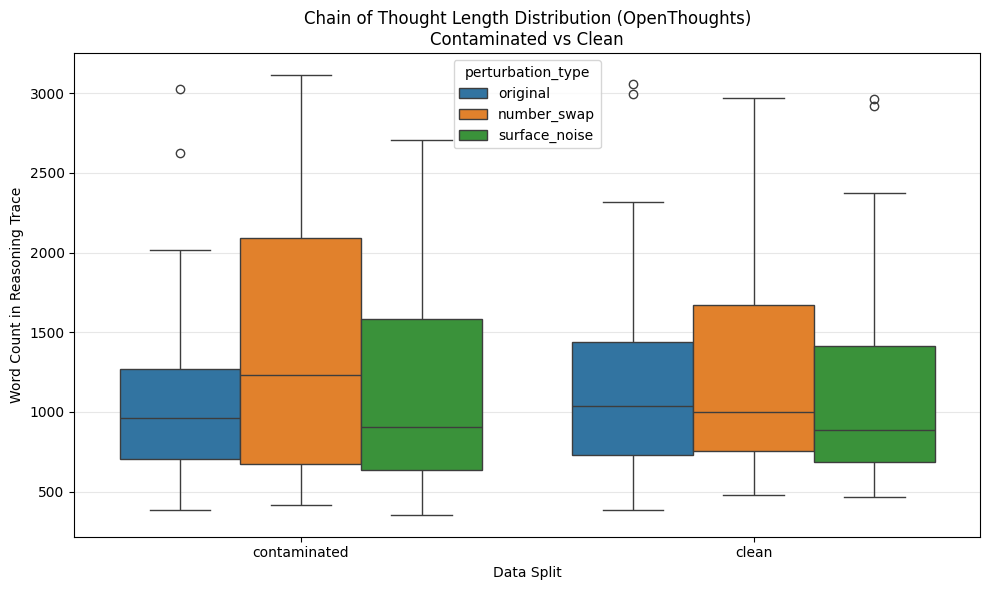

In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Load the specific openthoughts traces
fp = OUT_DIR / "did_traces_openthoughts.jsonl"
traces = []
if fp.exists():
    with open(fp) as f:
        for line in f:
            try:
                traces.append(json.loads(line))
            except:
                pass

df_ot = pd.DataFrame(traces)

# 2. Extract Chain of Thought length
def extract_thought_length(trace_text):
    if not isinstance(trace_text, str):
        return np.nan

    # Extract everything between begin and end thought tags
    match = re.search(r'<\|begin_of_thought\|>(.*?)<\|end_of_thought\|>', trace_text, re.DOTALL)
    if match:
        thought_text = match.group(1)
        return len(thought_text.split()) # Returns word count of the thought process

    # Fallback if tags are missing or malformed
    return len(trace_text.split())

if not df_ot.empty:
    df_ot['thought_word_count'] = df_ot['full_trace'].apply(extract_thought_length)

    # 3. Print Summary Statistics
    print("=== OpenThoughts CoT Word Count Summary ===")
    summary = df_ot.groupby(['split', 'perturbation_type'])['thought_word_count'].agg(['mean', 'median', 'std', 'count']).round(2)
    display(summary)

    # 4. Plot distributions
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_ot, x='split', y='thought_word_count', hue='perturbation_type',
                order=['contaminated', 'clean'])
    plt.title("Chain of Thought Length Distribution (OpenThoughts)\nContaminated vs Clean")
    plt.ylabel("Word Count in Reasoning Trace")
    plt.xlabel("Data Split")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No OpenThoughts traces found to analyze.")

### Mechanistic Analysis: Attention Entropy & Logit Lens

1. **Attention Entropy**: Examines whether attention is more focused (lower entropy) on contaminated samples, indicating direct retrieval from weights rather than diffuse reasoning.
2. **Logit Lens**: Applies the unembedding matrix to intermediate hidden states in the residual stream. If the correct answer token jumps to a high rank in earlier layers for contaminated samples, it strongly implies memorization.

Loading allenai/Llama-3.1-Tulu-3-8B-SFT in 4-bit for mechanistic analysis...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Running probe on Contaminated sample...
Running probe on Clean sample...


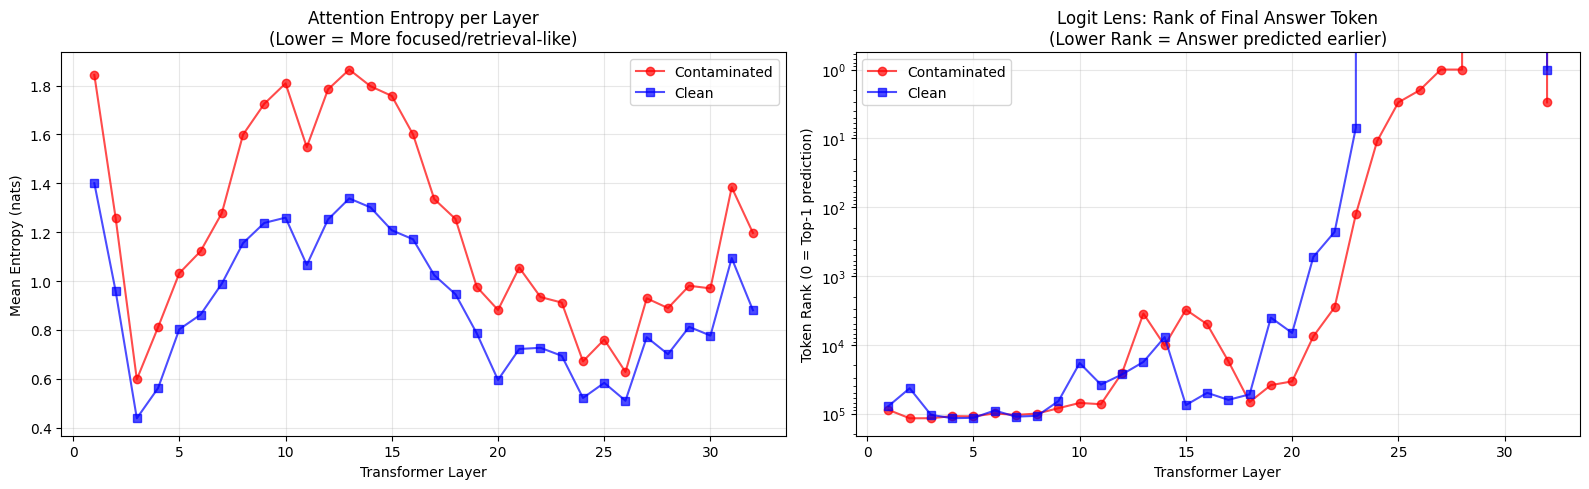

Mechanistic probe complete. Model unloaded.


In [16]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import csv

# --- Configuration ---
# We'll use Tulu (Llama-3 architecture) to demonstrate the mechanistic probing.
target_model = "tulu"
cfg = MODELS[target_model]

print(f"Loading {cfg['model_id']} in 4-bit for mechanistic analysis...")
# Load in 4-bit to ensure we don't OOM while storing massive attention tensors
tokenizer, model = load_model(cfg["model_id"], use_4bit=True)

# --- Data Fetching ---
# Fetch 1 Contaminated and 1 Clean problem from the original CSVs
with open(CONTAM_CSV) as f:
    contam_list = [r for r in csv.DictReader(f) if r["dataset"] == target_model and r["perturbation_type"] == "original"]
with open(CLEAN_CSV) as f:
    clean_list = [r for r in csv.DictReader(f) if r["dataset"] == target_model and r["perturbation_type"] == "original"]

contam_prob = contam_list[0] if contam_list else None
clean_prob = clean_list[0] if clean_list else None

# --- Probing Function ---
def run_mechanistic_probe(problem_dict):
    if not problem_dict:
        return None, None

    # Format prompt and teacher-force the ground truth answer to see internal states leading up to it
    messages = [{"role": "user", "content": problem_dict["problem"]}]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Append a structured suffix and the answer to trace the final token prediction
    gt_answer = str(problem_dict["answer"])
    full_text = prompt_text + "\nThe final answer is " + gt_answer

    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        # output_hidden_states & output_attentions are native Hugging Face hooks
        outputs = model(**inputs, output_hidden_states=True, output_attentions=True)

    hidden_states = outputs.hidden_states # tuple of (num_layers + 1)
    attentions = outputs.attentions       # tuple of (num_layers)

    # 1. Attention Entropy (average over heads and sequence for each layer)
    layer_entropies = []
    for att in attentions:
        # att shape: (batch, num_heads, seq_len, seq_len)
        # Cast to float32 to prevent float16 underflow/NaNs when attention is exactly 0
        att_fp32 = att.to(torch.float32)
        # Calculate entropy: -sum(p * log(p))
        entropy = -torch.sum(att_fp32 * torch.log(torch.clamp(att_fp32, min=1e-10)), dim=-1)
        layer_entropies.append(entropy.mean().item())

    # 2. Logit Lens: how early does the model predict the final answer token?
    # We look at the predictions at the token just BEFORE the last ground truth token
    target_token_id = inputs.input_ids[0, -1].item()

    layer_ranks = []
    for h in hidden_states[1:]: # Skip embedding layer (index 0)
        # Apply Llama RMSNorm and lm_head to intermediate states
        if hasattr(model.model, 'norm'):
            normed_h = model.model.norm(h)
        else:
            normed_h = h # Fallback if architecture differs slightly

        logits = model.lm_head(normed_h)

        # Logits for the token PRECEDING the last token (index -2)
        last_step_logits = logits[0, -2, :]

        # Calculate rank of the actual target token (0-indexed rank)
        sorted_indices = last_step_logits.argsort(descending=True)
        rank = (sorted_indices == target_token_id).nonzero(as_tuple=True)[0].item()
        layer_ranks.append(rank)

    return layer_entropies, layer_ranks

if contam_prob and clean_prob:
    print("Running probe on Contaminated sample...")
    contam_entropy, contam_ranks = run_mechanistic_probe(contam_prob)

    print("Running probe on Clean sample...")
    clean_entropy, clean_ranks = run_mechanistic_probe(clean_prob)

    # --- Plotting ---
    layers = list(range(1, len(contam_entropy) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: Attention Entropy
    ax1.plot(layers, contam_entropy, label='Contaminated', marker='o', color='red', alpha=0.7)
    ax1.plot(layers, clean_entropy, label='Clean', marker='s', color='blue', alpha=0.7)
    ax1.set_title("Attention Entropy per Layer\n(Lower = More focused/retrieval-like)")
    ax1.set_xlabel("Transformer Layer")
    ax1.set_ylabel("Mean Entropy (nats)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Logit Lens (Rank)
    ax2.plot(layers, contam_ranks, label='Contaminated', marker='o', color='red', alpha=0.7)
    ax2.plot(layers, clean_ranks, label='Clean', marker='s', color='blue', alpha=0.7)
    ax2.set_title("Logit Lens: Rank of Final Answer Token\n(Lower Rank = Answer predicted earlier)")
    ax2.set_xlabel("Transformer Layer")
    ax2.set_ylabel("Token Rank (0 = Top-1 prediction)")
    ax2.set_yscale("log") # Log scale for ranks (e.g., from 1 to 100,000 vocab size)
    ax2.invert_yaxis()    # Invert so higher on the graph = better rank (closer to 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Could not find required samples in the CSVs.")

# Free memory to ensure the notebook remains stable
del model, tokenizer
free_memory()
print("Mechanistic probe complete. Model unloaded.")

### Aggregated Mechanistic Probing: Subject $\times$ Level (OpenThoughts)
Compares Attention Entropy and Logit Lens rankings between contaminated and clean samples, aggregated by problem Subject and Difficulty Level.

Loading open-thoughts/OpenThinker-7B in 4-bit for aggregated mechanistic analysis...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Qwen2Model is using Qwen2SdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
The attention layers in this model are transitioning from computing the RoPE embeddings internally through `position_ids` (2D tensor with the indexes of the tokens), to using externally computed `position_embeddings` (Tuple of tensors, containing cos and sin). In v4.46 `position_ids` will be removed and `position_embeddings` will be mandatory.


Found 18 matching (Subject, Level) buckets for openthoughts.

Processing Bucket: Algebra (Level 1)


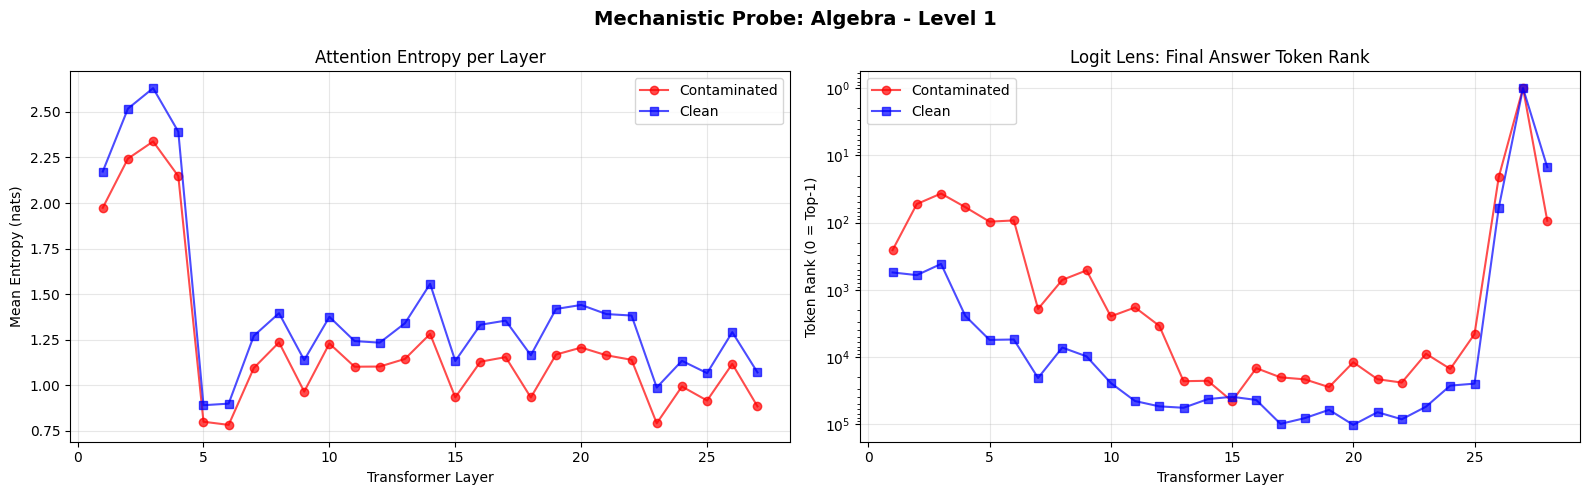


Processing Bucket: Algebra (Level 3)


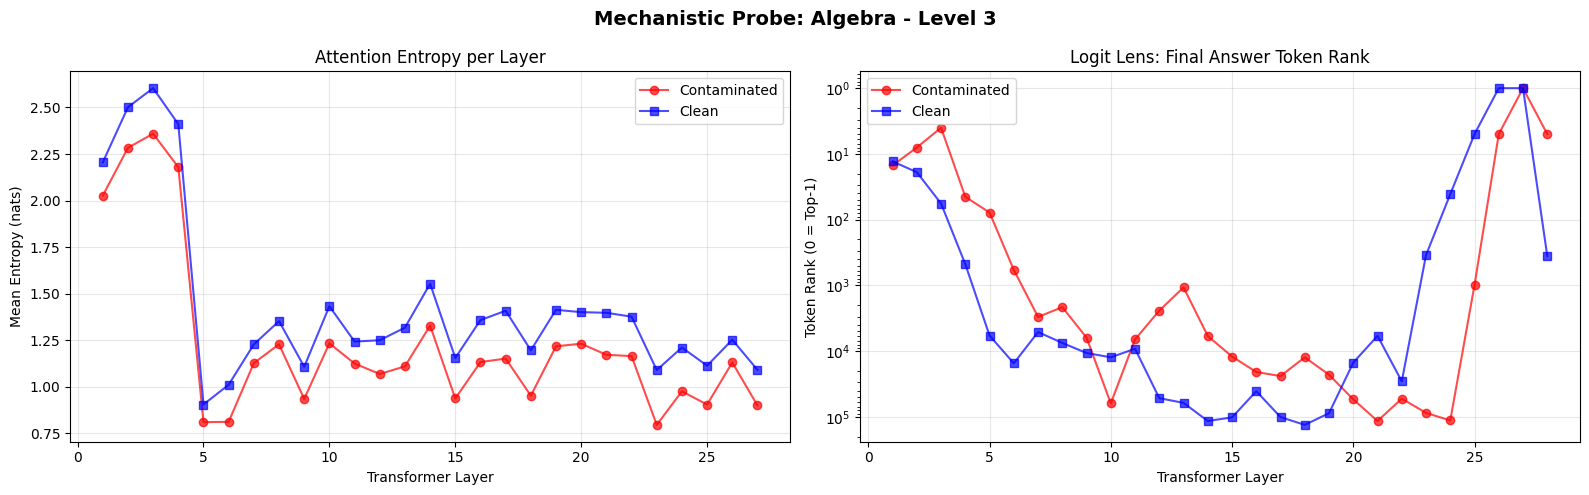


Processing Bucket: Algebra (Level 4)


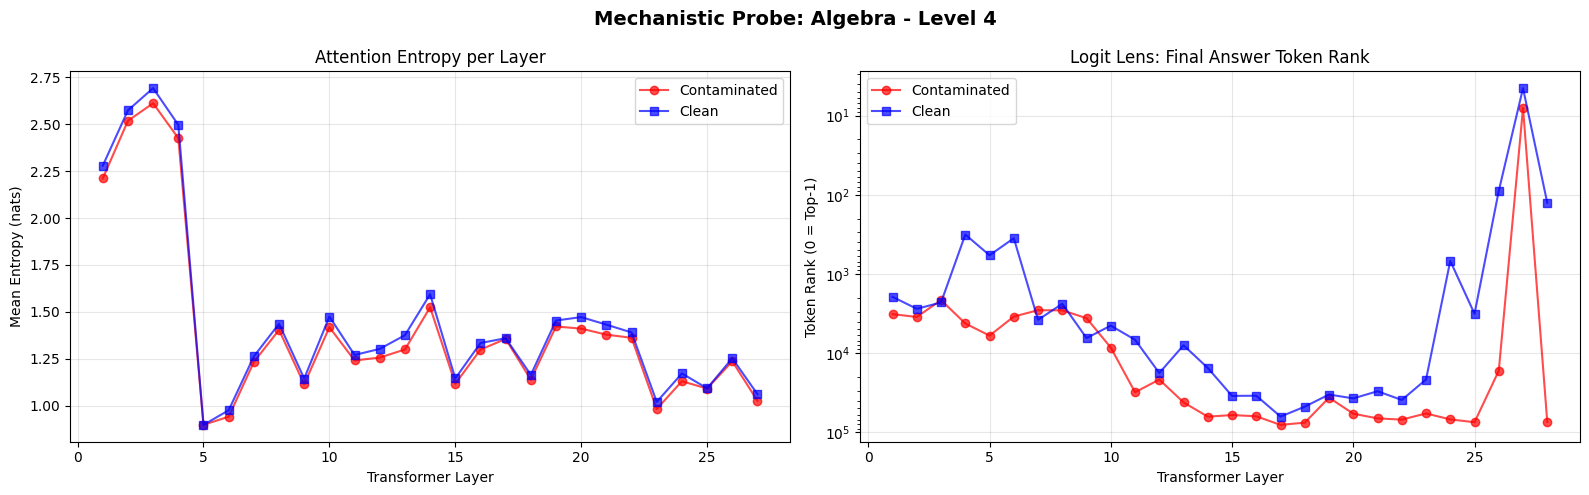


Processing Bucket: Algebra (Level 5)


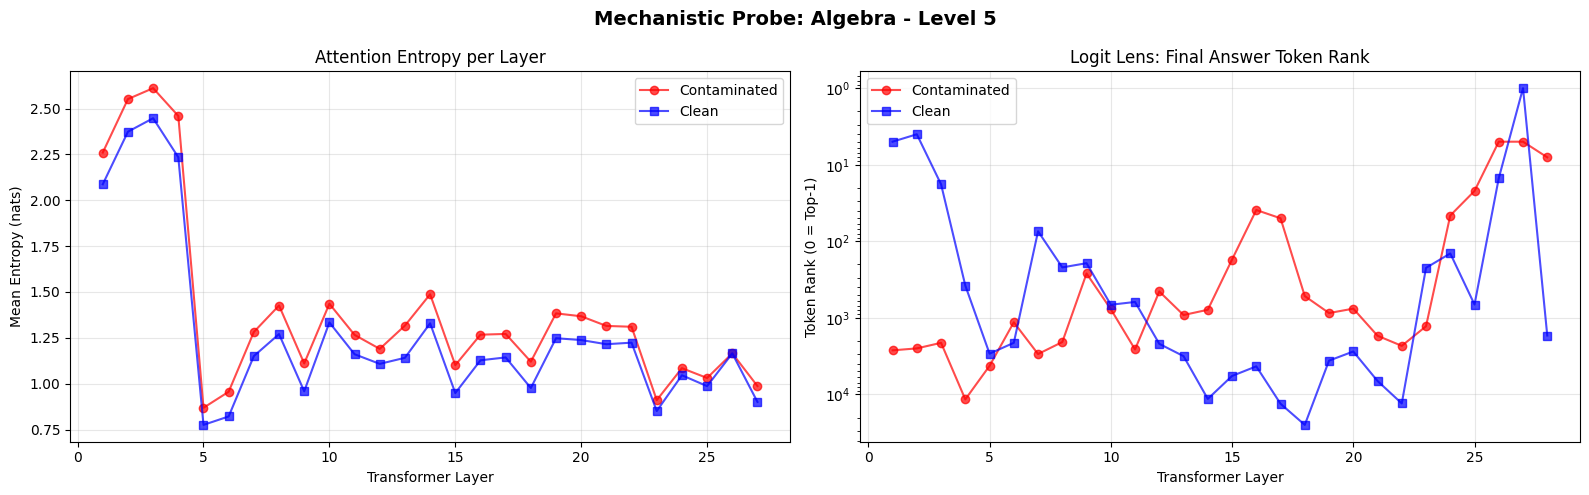


Processing Bucket: Counting & Probability (Level 4)


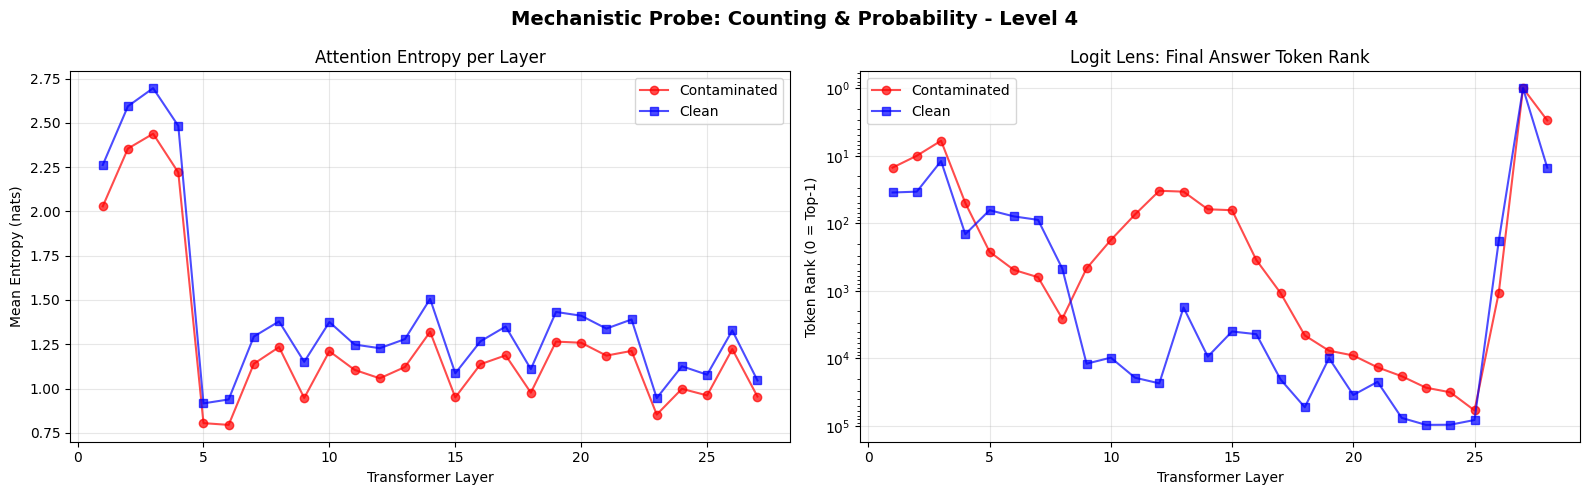


Processing Bucket: Counting & Probability (Level 5)


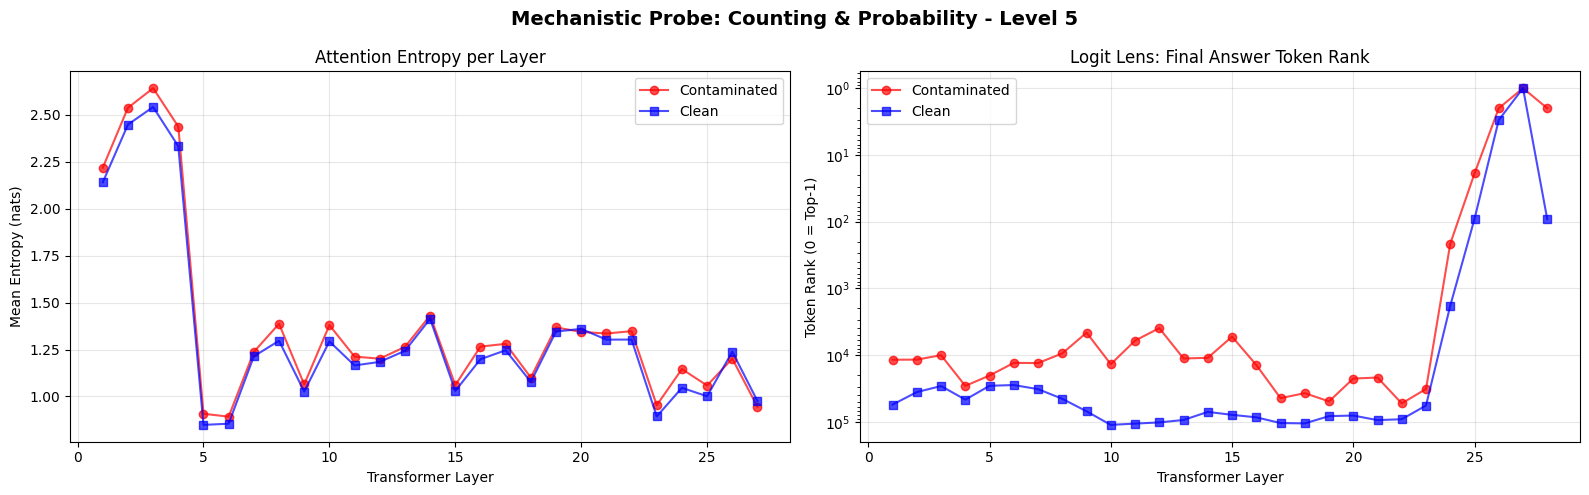


Processing Bucket: Geometry (Level 2)


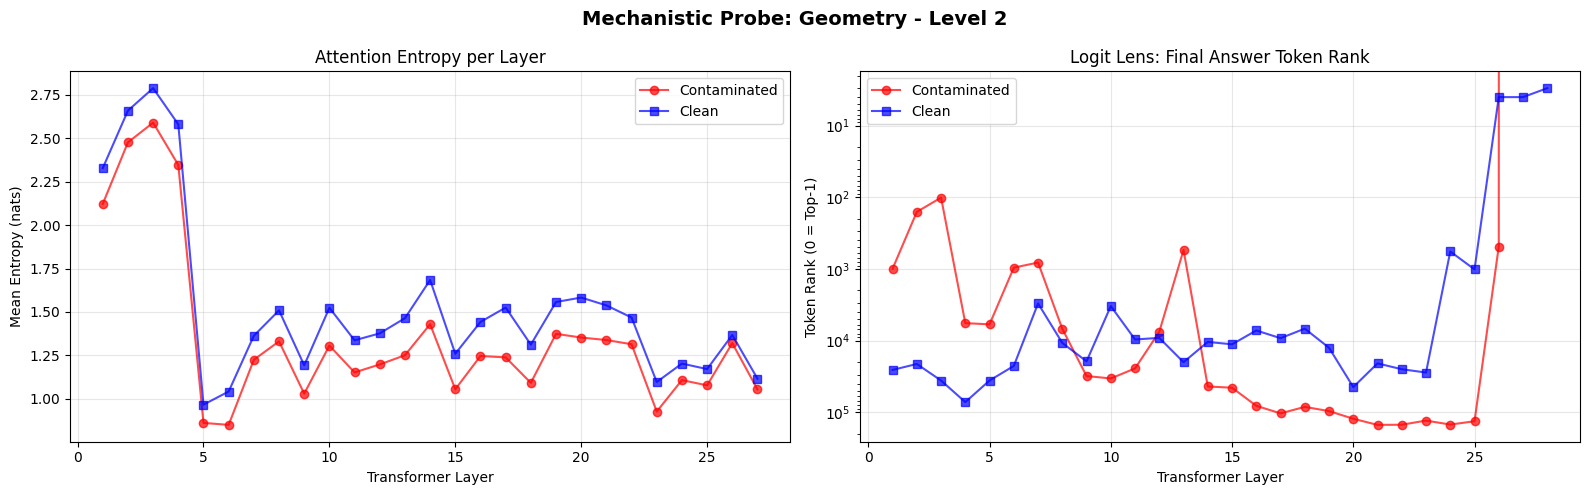


Processing Bucket: Geometry (Level 5)


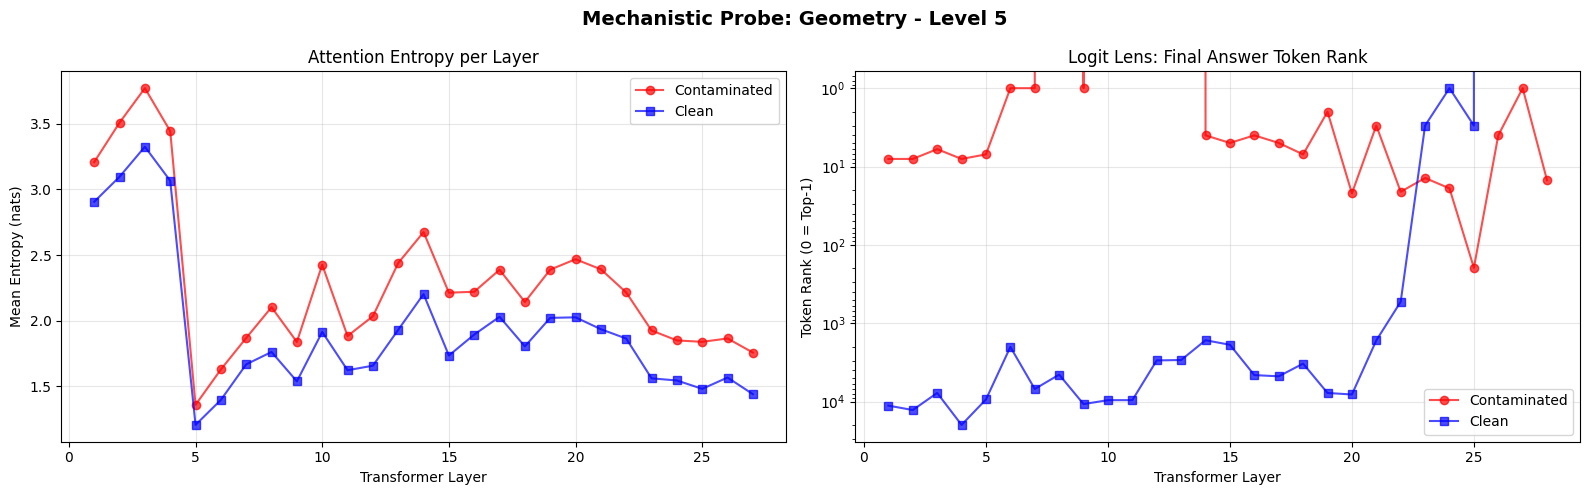


Processing Bucket: Intermediate Algebra (Level 1)


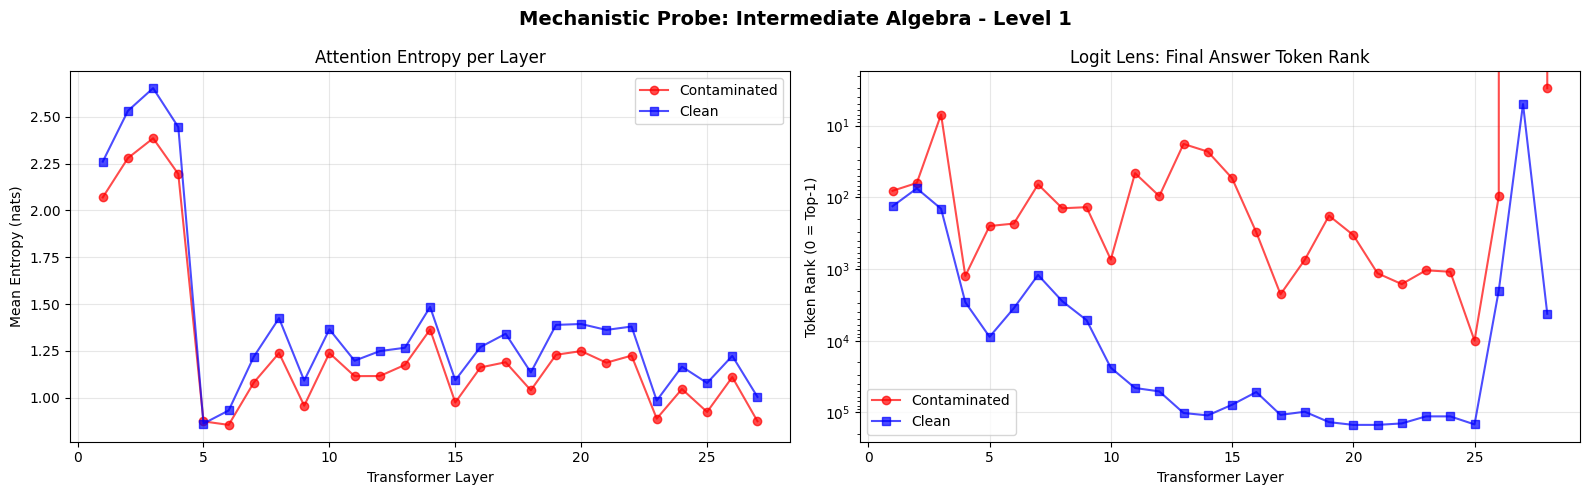


Processing Bucket: Intermediate Algebra (Level 2)


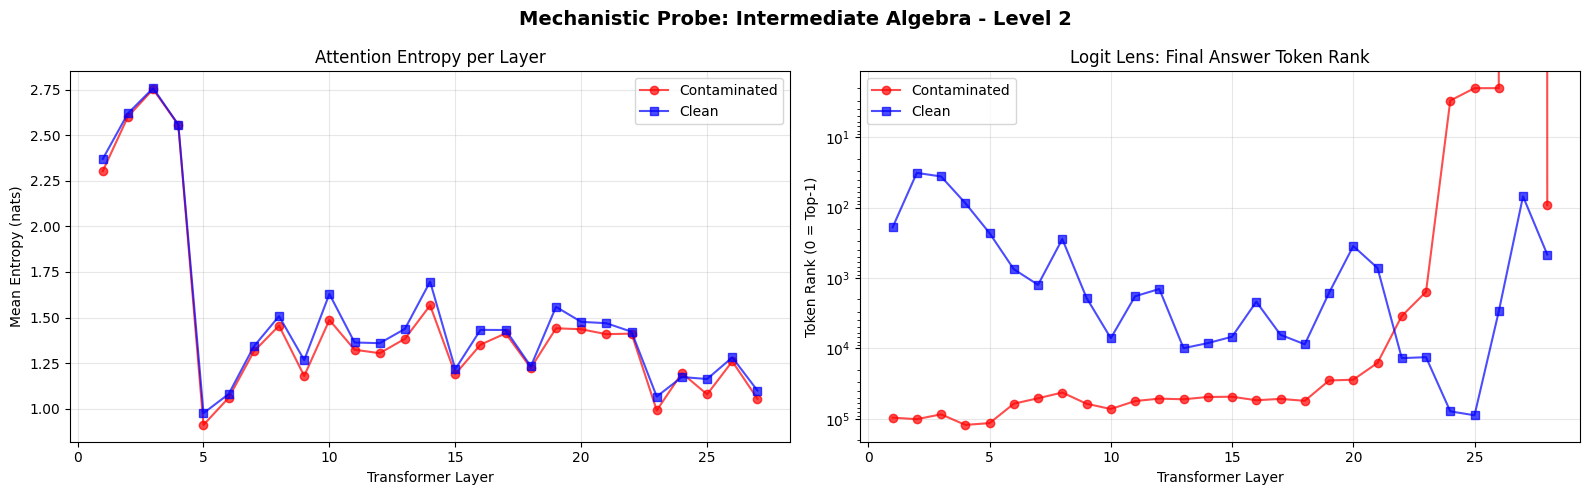


Processing Bucket: Intermediate Algebra (Level 3)


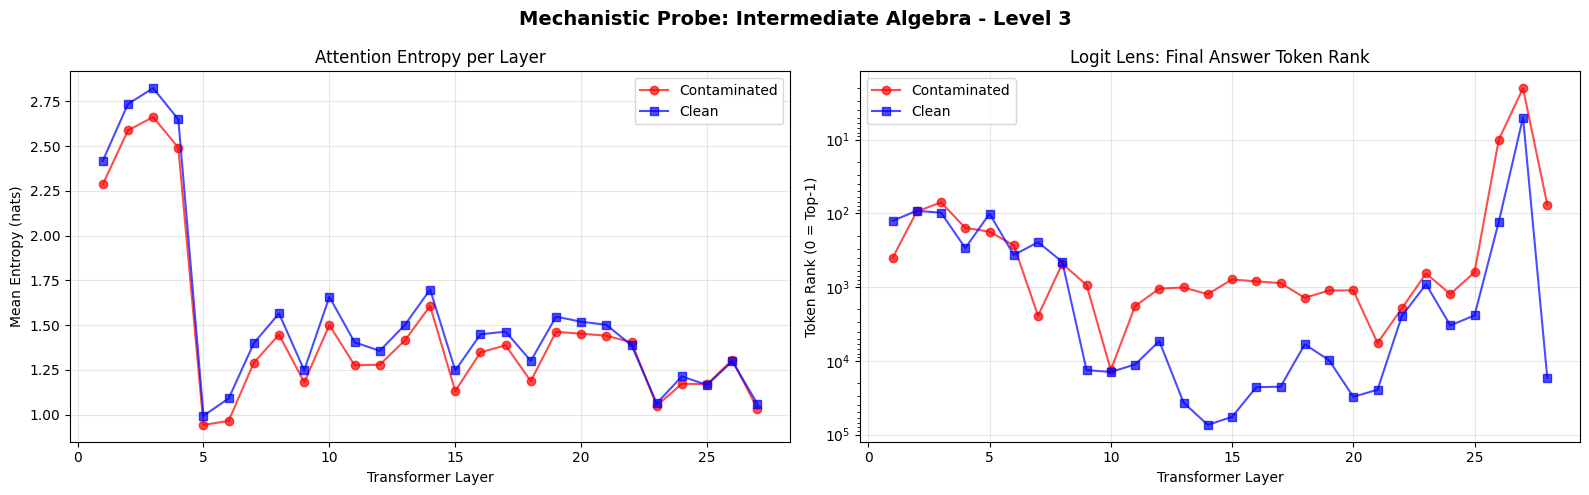


Processing Bucket: Intermediate Algebra (Level 4)


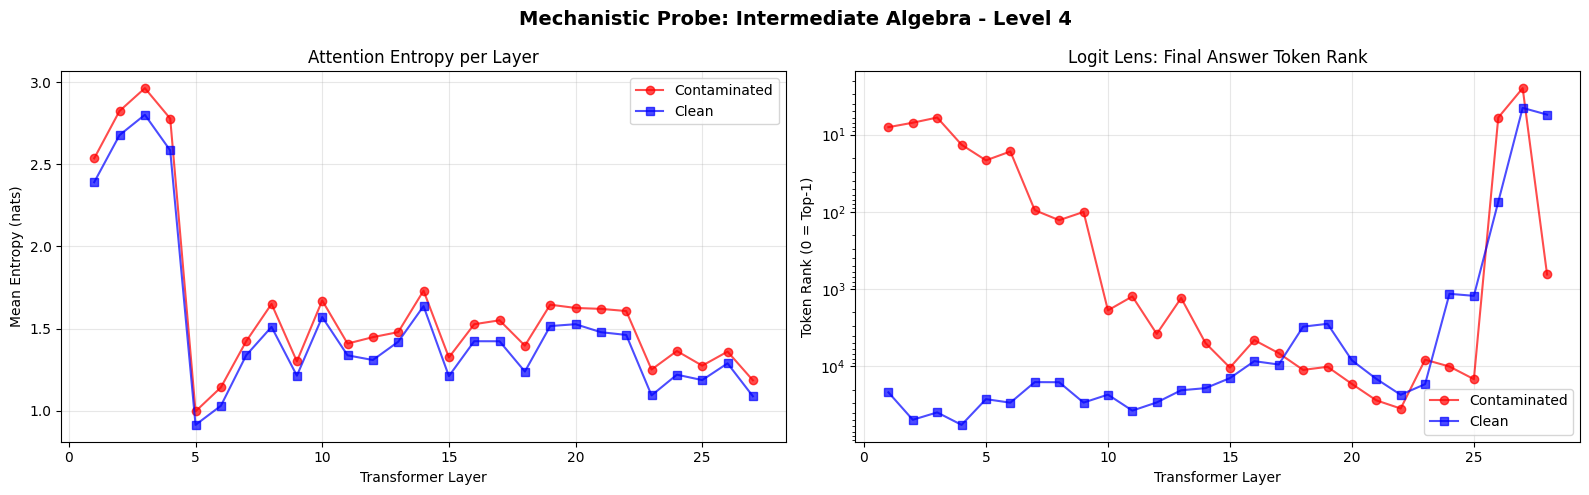


Processing Bucket: Intermediate Algebra (Level 5)


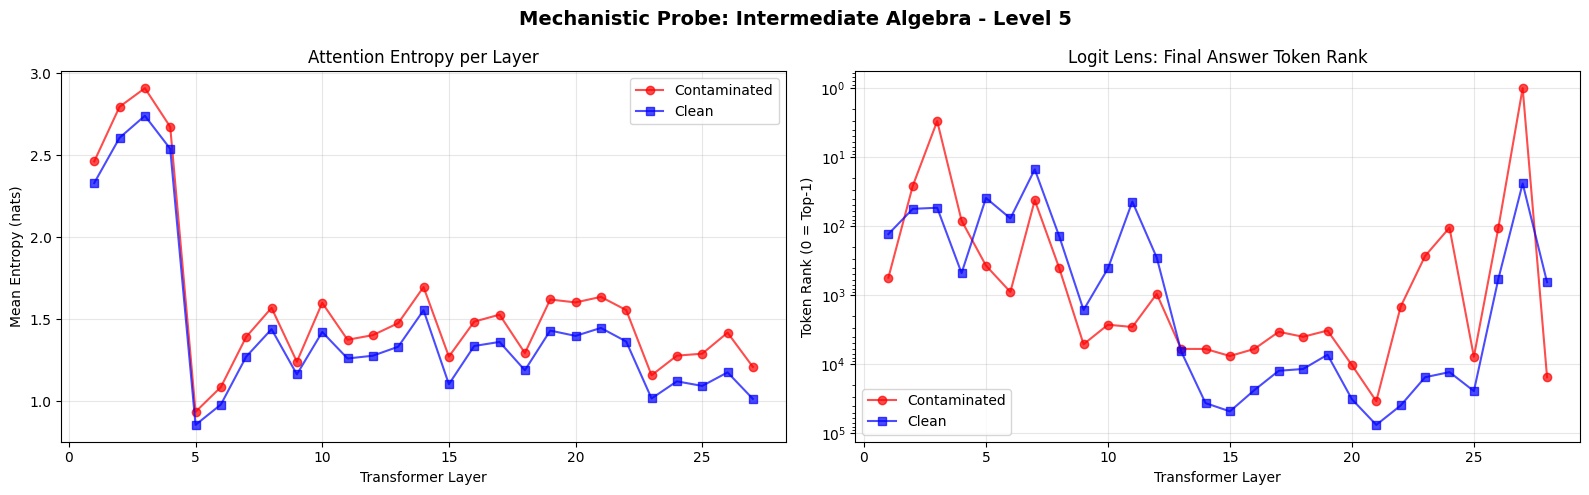


Processing Bucket: Number Theory (Level 4)


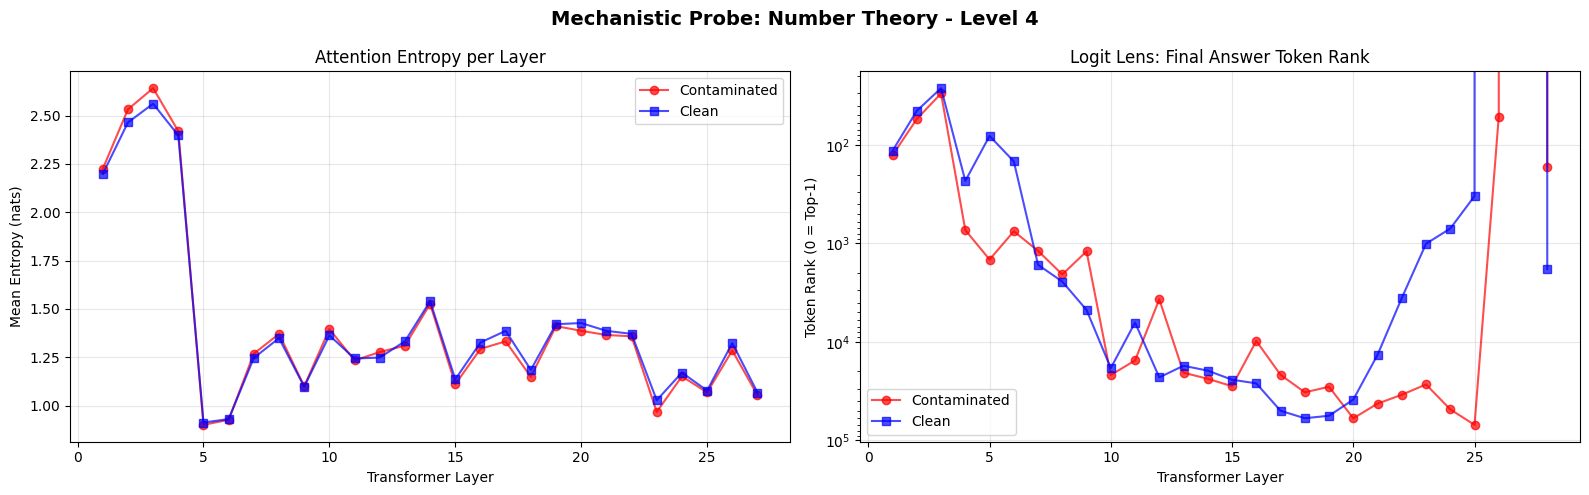


Processing Bucket: Prealgebra (Level 2)


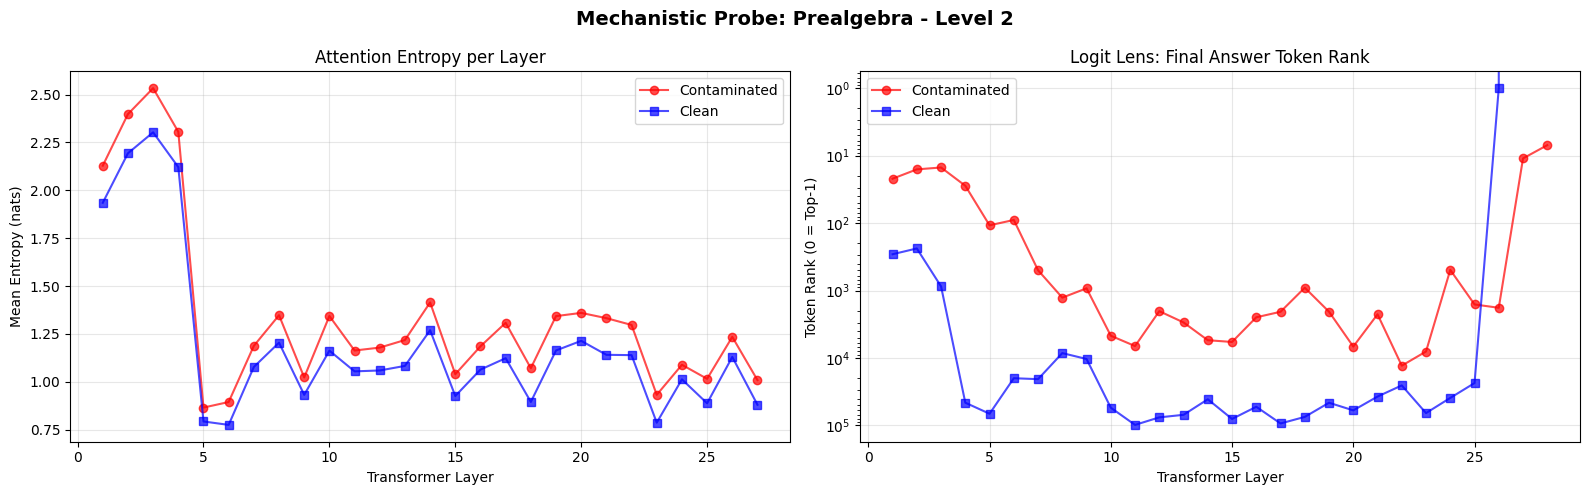


Processing Bucket: Prealgebra (Level 5)


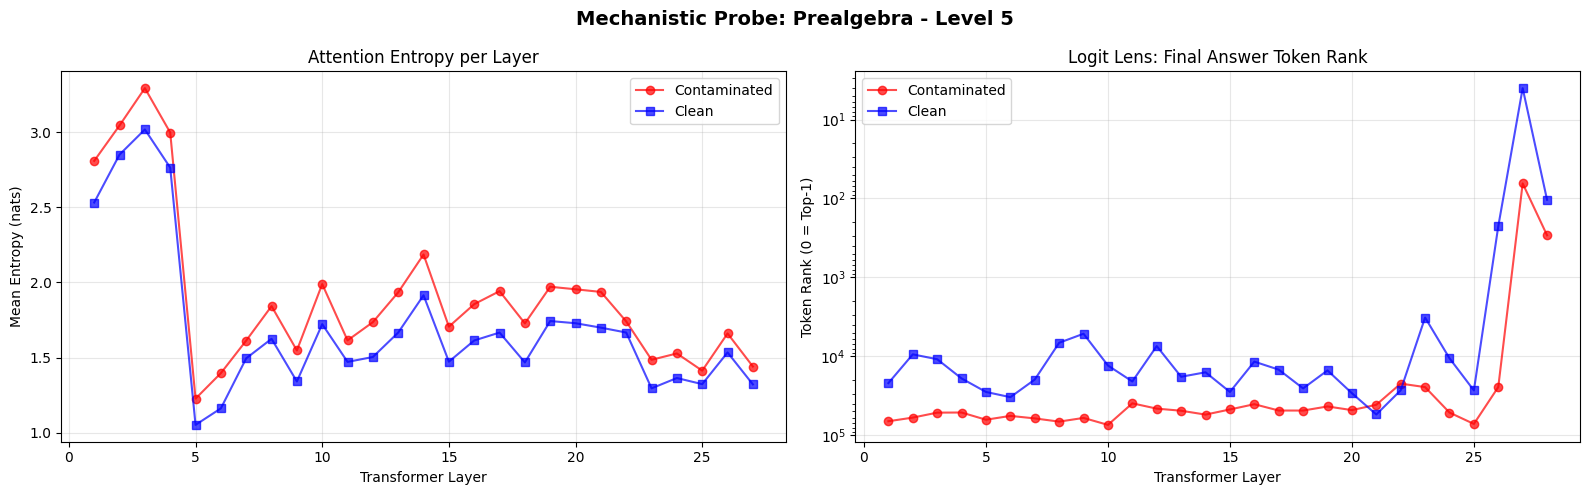


Processing Bucket: Precalculus (Level 2)


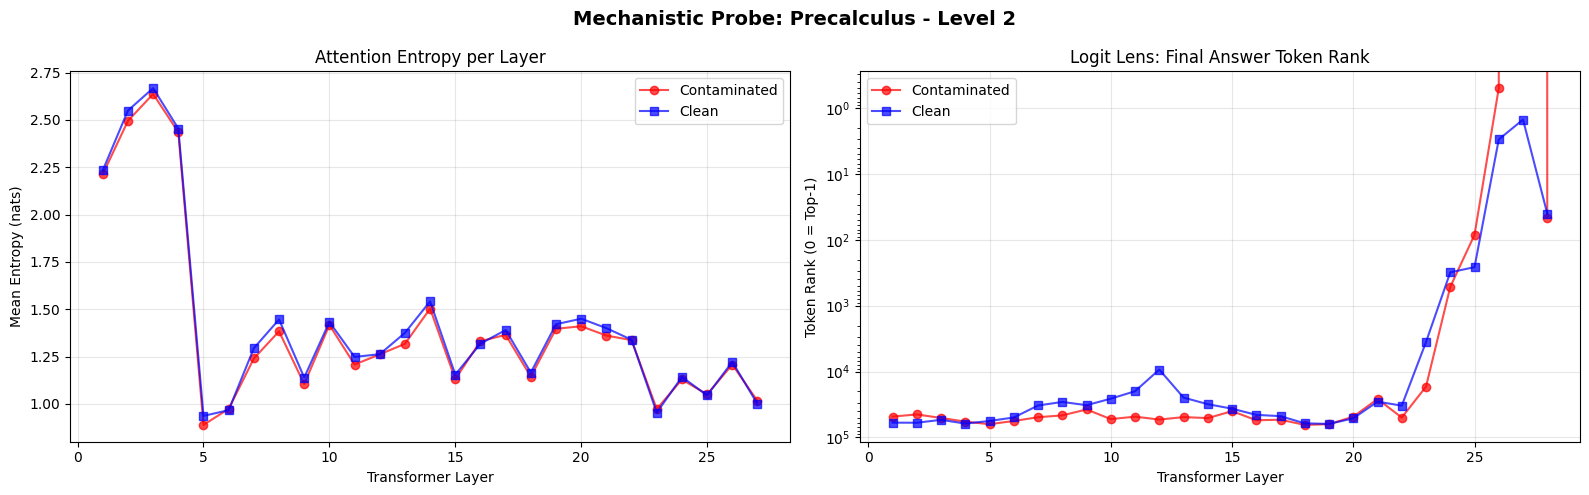


Processing Bucket: Precalculus (Level 3)


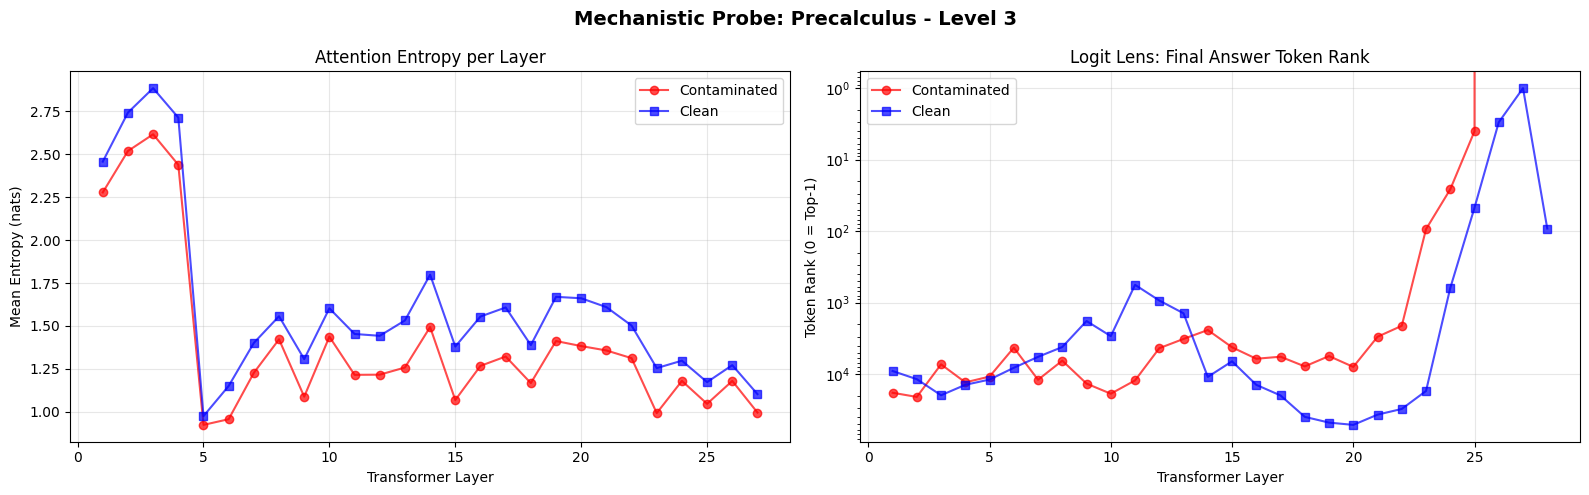

Aggregated mechanistic probing complete.


In [18]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from collections import defaultdict
import numpy as np
import gc

# --- Configuration ---
target_model = "openthoughts"
cfg = MODELS[target_model]
max_samples_per_bucket = 2 # Limit to prevent extreme runtimes/OOM

print(f"Loading {cfg['model_id']} in 4-bit for aggregated mechanistic analysis...")
tokenizer, model = load_model(cfg["model_id"], use_4bit=True)

# --- Data Fetching & Grouping ---
contam_grouped = defaultdict(list)
clean_grouped = defaultdict(list)

with open(CONTAM_CSV) as f:
    for r in csv.DictReader(f):
        if r["dataset"] == target_model and r["perturbation_type"] == "original":
            contam_grouped[(r["math500_subject"], r["math500_level"])].append(r)

with open(CLEAN_CSV) as f:
    for r in csv.DictReader(f):
        if r["dataset"] == target_model and r["perturbation_type"] == "original":
            clean_grouped[(r["math500_subject"], r["math500_level"])].append(r)

common_buckets = sorted(list(set(contam_grouped.keys()).intersection(set(clean_grouped.keys()))))
print(f"Found {len(common_buckets)} matching (Subject, Level) buckets for {target_model}.")

# --- Probing Function ---
def run_mechanistic_probe(problem_dict):
    messages = [{"role": "user", "content": problem_dict["problem"]}]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    gt_answer = str(problem_dict["answer"])
    full_text = prompt_text + "\nThe final answer is " + gt_answer

    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, output_attentions=True)

    layer_entropies = []
    for att in outputs.attentions:
        att_fp32 = att.to(torch.float32)
        entropy = -torch.sum(att_fp32 * torch.log(torch.clamp(att_fp32, min=1e-10)), dim=-1)
        layer_entropies.append(entropy.mean().item())

    target_token_id = inputs.input_ids[0, -1].item()
    layer_ranks = []
    for h in outputs.hidden_states[1:]:
        if hasattr(model.model, 'norm'):
            normed_h = model.model.norm(h)
        else:
            normed_h = h

        logits = model.lm_head(normed_h)
        last_step_logits = logits[0, -2, :]
        sorted_indices = last_step_logits.argsort(descending=True)
        rank = (sorted_indices == target_token_id).nonzero(as_tuple=True)[0].item()
        layer_ranks.append(rank)

    del outputs, inputs
    torch.cuda.empty_cache()

    return layer_entropies, layer_ranks

# --- Execution & Plotting ---
for subject, level in common_buckets:
    print(f"\nProcessing Bucket: {subject} (Level {level})")

    contam_samples = contam_grouped[(subject, level)][:max_samples_per_bucket]
    clean_samples = clean_grouped[(subject, level)][:max_samples_per_bucket]

    bucket_contam_entropies, bucket_contam_ranks = [], []
    bucket_clean_entropies, bucket_clean_ranks = [], []

    # Process Contaminated
    for p in contam_samples:
        e, r = run_mechanistic_probe(p)
        bucket_contam_entropies.append(e)
        bucket_contam_ranks.append(r)

    # Process Clean
    for p in clean_samples:
        e, r = run_mechanistic_probe(p)
        bucket_clean_entropies.append(e)
        bucket_clean_ranks.append(r)

    if not bucket_contam_entropies or not bucket_clean_entropies:
        continue

    # Aggregate
    avg_contam_entropy = np.mean(bucket_contam_entropies, axis=0)
    avg_contam_rank = np.mean(bucket_contam_ranks, axis=0)
    avg_clean_entropy = np.mean(bucket_clean_entropies, axis=0)
    avg_clean_rank = np.mean(bucket_clean_ranks, axis=0)

    layers = list(range(1, len(avg_contam_entropy) + 1))

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Mechanistic Probe: {subject} - Level {level}", fontsize=14, fontweight="bold")

    ax1.plot(layers, avg_contam_entropy, label='Contaminated', marker='o', color='red', alpha=0.7)
    ax1.plot(layers, avg_clean_entropy, label='Clean', marker='s', color='blue', alpha=0.7)
    ax1.set_title("Attention Entropy per Layer")
    ax1.set_xlabel("Transformer Layer")
    ax1.set_ylabel("Mean Entropy (nats)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(layers, avg_contam_rank, label='Contaminated', marker='o', color='red', alpha=0.7)
    ax2.plot(layers, avg_clean_rank, label='Clean', marker='s', color='blue', alpha=0.7)
    ax2.set_title("Logit Lens: Final Answer Token Rank")
    ax2.set_xlabel("Transformer Layer")
    ax2.set_ylabel("Token Rank (0 = Top-1)")
    ax2.set_yscale("log")
    ax2.invert_yaxis()
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Cleanup
del model, tokenizer
free_memory()
print("Aggregated mechanistic probing complete.")


### Quantitative Analysis: Mechanistic Differences (Clean vs Contaminated)
Summarizes the average Attention Entropy and Logit Lens Rank across all layers, calculating the numerical difference (`Clean - Contaminated`) for each Subject and Level.

In [21]:
import torch
import pandas as pd
import numpy as np
import csv
from collections import defaultdict
from IPython.display import display

# --- Configuration ---
target_model = "openthoughts"
cfg = MODELS[target_model]
max_samples_per_bucket = 2

print(f"Loading {cfg['model_id']} in 4-bit to quantify mechanistic differences...")
tokenizer, model = load_model(cfg["model_id"], use_4bit=True)

# --- Data Fetching & Grouping ---
contam_grouped = defaultdict(list)
clean_grouped = defaultdict(list)

with open(CONTAM_CSV) as f:
    for r in csv.DictReader(f):
        if r["dataset"] == target_model and r["perturbation_type"] == "original":
            contam_grouped[(r["math500_subject"], r["math500_level"])].append(r)

with open(CLEAN_CSV) as f:
    for r in csv.DictReader(f):
        if r["dataset"] == target_model and r["perturbation_type"] == "original":
            clean_grouped[(r["math500_subject"], r["math500_level"])].append(r)

common_buckets = sorted(list(set(contam_grouped.keys()).intersection(set(clean_grouped.keys()))))

# --- Probing Function (Returns Means across layers) ---
def get_probe_means(problem_dict):
    messages = [{"role": "user", "content": problem_dict["problem"]}]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    gt_answer = str(problem_dict["answer"])
    full_text = prompt_text + "\nThe final answer is " + gt_answer

    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, output_attentions=True)

    # Average Entropy across all layers for this sample
    layer_entropies = []
    for att in outputs.attentions:
        att_fp32 = att.to(torch.float32)
        entropy = -torch.sum(att_fp32 * torch.log(torch.clamp(att_fp32, min=1e-10)), dim=-1)
        # Use torch.nanmean to ignore NaN values from masking/quantization
        layer_entropies.append(torch.nanmean(entropy).item())
    # Use np.nanmean to safely aggregate
    mean_entropy = np.nanmean(layer_entropies)

    # Average Logit Rank across all layers for this sample
    target_token_id = inputs.input_ids[0, -1].item()
    layer_ranks = []
    for h in outputs.hidden_states[1:]:
        normed_h = model.model.norm(h) if hasattr(model.model, 'norm') else h
        logits = model.lm_head(normed_h)
        last_step_logits = logits[0, -2, :]
        sorted_indices = last_step_logits.argsort(descending=True)
        rank = (sorted_indices == target_token_id).nonzero(as_tuple=True)[0].item()
        layer_ranks.append(rank)
    mean_rank = np.nanmean(layer_ranks)

    del outputs, inputs
    torch.cuda.empty_cache()
    return mean_entropy, mean_rank

# --- Execution ---
results = []

for subject, level in common_buckets:
    c_samples = contam_grouped[(subject, level)][:max_samples_per_bucket]
    n_samples = clean_grouped[(subject, level)][:max_samples_per_bucket]

    c_ent, c_rank = [], []
    n_ent, n_rank = [], []

    for p in c_samples:
        e, r = get_probe_means(p)
        c_ent.append(e)
        c_rank.append(r)

    for p in n_samples:
        e, r = get_probe_means(p)
        n_ent.append(e)
        n_rank.append(r)

    if c_ent and n_ent:
        results.append({
            "Subject": subject,
            "Level": level,
            "Contam_Entropy": np.nanmean(c_ent),
            "Clean_Entropy": np.nanmean(n_ent),
            "Entropy_Diff (Clean-Contam)": np.nanmean(n_ent) - np.nanmean(c_ent),
            "Contam_Rank": np.nanmean(c_rank),
            "Clean_Rank": np.nanmean(n_rank),
            "Rank_Diff (Clean-Contam)": np.nanmean(n_rank) - np.nanmean(c_rank),
        })

df_mech = pd.DataFrame(results)
display(df_mech.round(2))

print("\n=== Overall Aggregated Differences (Across all buckets) ===")
print(f"Average Entropy Diff (Clean - Contam): {df_mech['Entropy_Diff (Clean-Contam)'].mean():.3f} nats")
print(f"Average Rank Diff (Clean - Contam):    {df_mech['Rank_Diff (Clean-Contam)'].mean():.1f} rank positions")
print("(Positive differences mean the Clean samples have higher entropy/rank, indicating less memorization.)")

# Cleanup
del model, tokenizer
free_memory()
print("\nDone.")

Loading open-thoughts/OpenThinker-7B in 4-bit to quantify mechanistic differences...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

,Subject,Level,Contam_Entropy,Clean_Entropy,Entropy_Diff (Clean-Contam),Contam_Rank,Clean_Rank,Rank_Diff (Clean-Contam)
0,Algebra,1,1.22,1.42,0.20,9769.00,34351.86,24582.86
1,Algebra,3,1.23,1.43,0.20,21737.39,29011.29,7273.89
2,Algebra,4,1.41,1.45,0.04,35892.09,15023.73,-20868.36
3,Algebra,5,1.39,1.27,-0.12,1528.75,3607.89,2079.14
4,Counting & Probability,4,1.26,1.42,0.16,6365.25,20524.96,14159.71
5,Counting & Probability,5,1.38,1.33,-0.04,16046.68,58561.86,42515.18
6,Geometry,2,1.36,1.54,0.18,50410.50,16688.00,-33722.50
7,Geometry,5,2.30,1.94,-0.36,12.93,5158.25,5145.32
8,Intermediate Algebra,1,1.26,1.40,0.14,784.04,58857.46,58073.43
9,Intermediate Algebra,2,1.47,1.52,0.05,46788.64,9246.39,-37542.25



=== Overall Aggregated Differences (Across all buckets) ===
Average Entropy Diff (Clean - Contam): 0.007 nats
Average Rank Diff (Clean - Contam):    5295.1 rank positions
(Positive differences mean the Clean samples have higher entropy/rank, indicating less memorization.)

Done.


=== Mean Differences by Difficulty Level ===


,Level,Entropy_Diff (Clean-Contam),Rank_Diff (Clean-Contam)
0,1,0.17,41328.14
1,2,0.03,-10395.35
2,3,0.16,8321.26
3,4,0.02,314.99
4,5,-0.18,5602.79



=== Mean Differences by Subject ===


,Subject,Entropy_Diff (Clean-Contam),Rank_Diff (Clean-Contam)
0,Algebra,0.08,3266.88
1,Counting & Probability,0.06,28337.45
2,Geometry,-0.09,-14288.59
3,Intermediate Algebra,0.00,10506.87
4,Number Theory,0.00,-4472.70
5,Prealgebra,-0.18,3598.12
6,Precalculus,0.12,-555.29


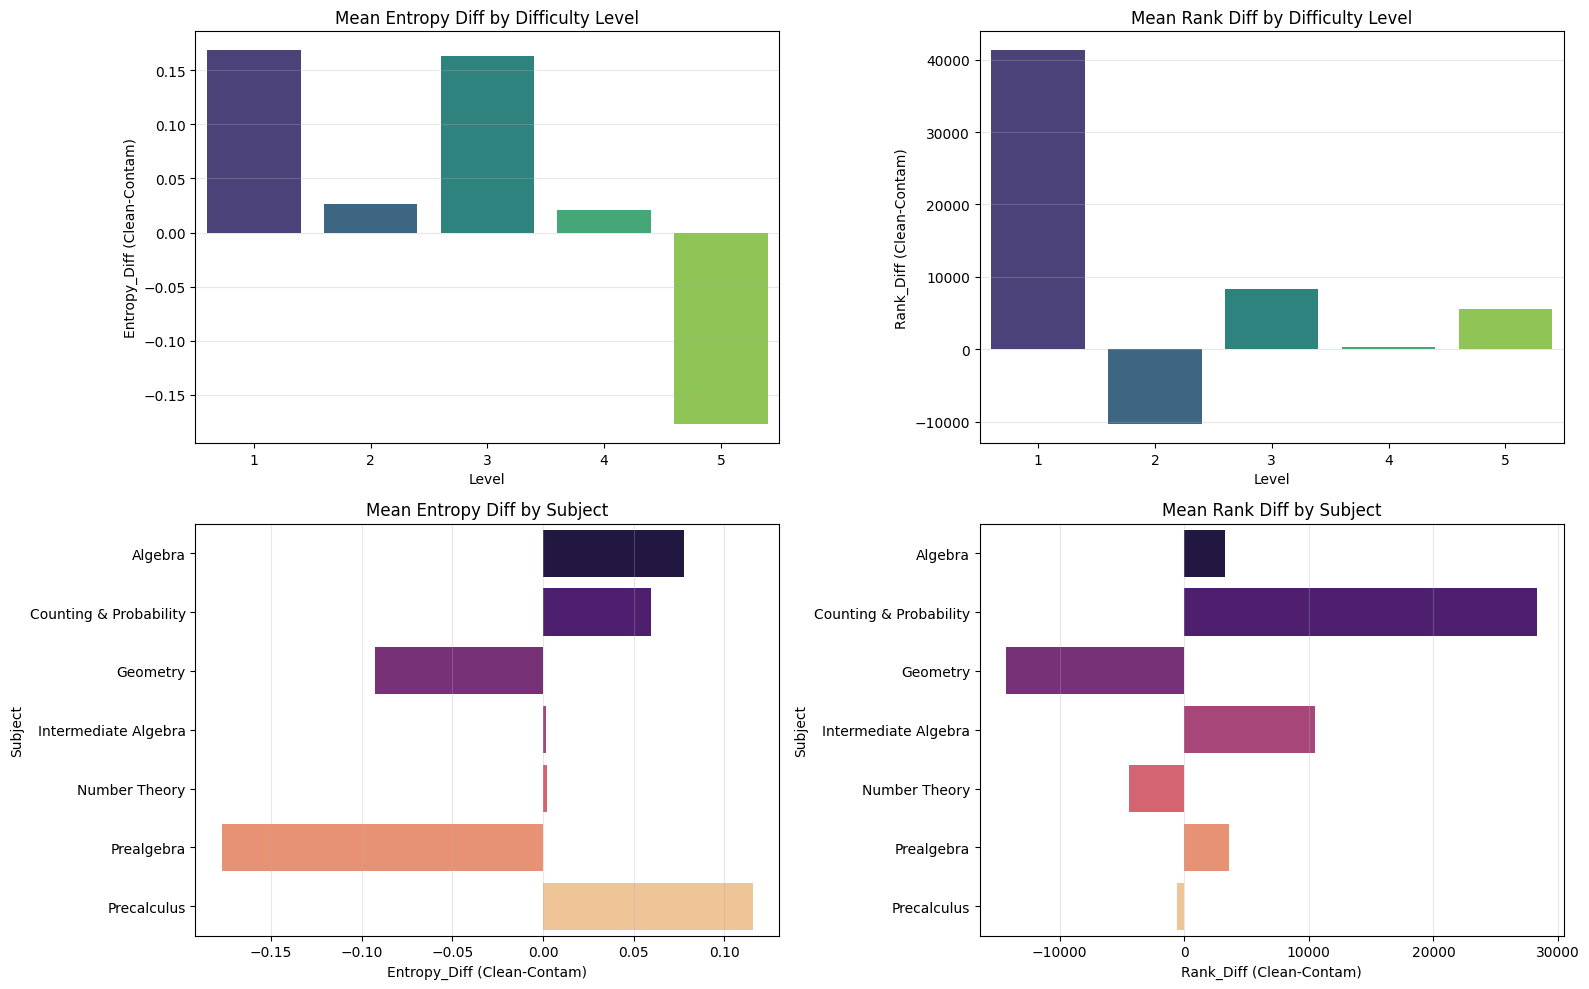

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_mech' in locals() and not df_mech.empty:
    # Aggregate by Level
    level_agg = df_mech.groupby('Level')[['Entropy_Diff (Clean-Contam)', 'Rank_Diff (Clean-Contam)']].mean().reset_index()
    print("=== Mean Differences by Difficulty Level ===")
    display(level_agg.round(2))

    # Aggregate by Subject
    subject_agg = df_mech.groupby('Subject')[['Entropy_Diff (Clean-Contam)', 'Rank_Diff (Clean-Contam)']].mean().reset_index()
    print("\n=== Mean Differences by Subject ===")
    display(subject_agg.round(2))

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=level_agg, x='Level', y='Entropy_Diff (Clean-Contam)', ax=axes[0, 0], hue='Level', legend=False, palette='viridis')
    axes[0, 0].set_title('Mean Entropy Diff by Difficulty Level')
    axes[0, 0].grid(axis='y', alpha=0.3)

    sns.barplot(data=level_agg, x='Level', y='Rank_Diff (Clean-Contam)', ax=axes[0, 1], hue='Level', legend=False, palette='viridis')
    axes[0, 1].set_title('Mean Rank Diff by Difficulty Level')
    axes[0, 1].grid(axis='y', alpha=0.3)

    sns.barplot(data=subject_agg, y='Subject', x='Entropy_Diff (Clean-Contam)', ax=axes[1, 0], hue='Subject', legend=False, palette='magma')
    axes[1, 0].set_title('Mean Entropy Diff by Subject')
    axes[1, 0].grid(axis='x', alpha=0.3)

    sns.barplot(data=subject_agg, y='Subject', x='Rank_Diff (Clean-Contam)', ax=axes[1, 1], hue='Subject', legend=False, palette='magma')
    axes[1, 1].set_title('Mean Rank Diff by Subject')
    axes[1, 1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("df_mech is not available. Please run the previous mechanistic probing cell first.")

## Analysis

Cells below load the per-model trace files, build a unified DataFrame, and report:
1. **Per-model 2×2 summary** — counts and accuracies for every (split × perturbation_type) cell.
2. **DiD effect** with 95% bootstrap CI (10k iterations, resampled by problem) and Welch's t-test on per-problem deltas — separately for `number_swap` and `surface_noise`.
3. **Recitation rate** — for `number_swap` contaminated rows, fraction whose final answer matches the *original* benchmark answer.
4. **Inflation estimate** per model: `(N_contaminated × DiD) / 500`.
5. **Plots** — per-model 2×2 bars and cross-model DiD comparison.
6. **θ sensitivity** (F6 from `recitation_findings.md`) — fraction of contaminated problems with Δ ≥ θ across thresholds.
7. **Similarity → Δ correlation** (F3) — Spearman between training similarity and per-problem Δ. Joins on `Annotation_CS288_Final.csv` (Tulu + OT only; S1 not in annotations).
8. **Type A vs Type B** (F5) — mean Δ by contamination type with Mann-Whitney U.

Note: F2 (majority-vote / pass@k) and F4 (entropy staircase) from `recitation_findings.md` require N>1 samples per prompt and are not computable at `N_SAMPLES=1`.

In [ ]:
# ── Load all trace files into a unified DataFrame ──────────────────────────────────────────
import pandas as pd, json

frames = []
for model_name in RUN_MODELS:
    fp = OUT_DIR / f"did_traces_{model_name}.jsonl"
    if not fp.exists():
        print(f"  [skip] {fp.name} not found")
        continue
    with open(fp) as f:
        for line in f:
            frames.append(json.loads(line))

df = pd.DataFrame(frames)
print(f"Loaded {len(df)} trace rows across {df['model'].nunique() if len(df) else 0} model(s)")
if len(df) == 0:
    raise RuntimeError("No traces found — run the inference loop first.")

# Coerce types
df["correct"] = df["correct"].astype("boolean")  # nullable bool
df["level"]   = pd.to_numeric(df["level"], errors="coerce")

# Add original benchmark answer for recitation analysis
orig = (df[df.perturbation_type == "original"]
        [["model", "split", "math500_id", "ground_truth"]]
        .rename(columns={"ground_truth": "original_answer"}))
df = df.merge(orig, on=["model", "split", "math500_id"], how="left")

df["original_answer_norm"] = df["original_answer"].apply(
    lambda s: normalize_answer(s) if pd.notna(s) else None
)
# `final_answer` was already normalised at write time
df["recited_original"] = (
    df["final_answer"].notna()
    & df["original_answer_norm"].notna()
    & (df["final_answer"] == df["original_answer_norm"])
)

# Extraction-failure rate
n_no_extract = df["final_answer"].isna().sum()
print(f"Extraction failures (no \\boxed{{}} found): {n_no_extract} / {len(df)} ({n_no_extract / len(df):.1%})")

# Per-model row counts
print()
print(df.groupby(["model", "split", "perturbation_type"]).size().unstack(fill_value=0))

In [ ]:
# ── Per-model 2x2 cell summary ─────────────────────────────────────────────────────────
import numpy as np

def cell_summary(d):
    correct = d["correct"].dropna().astype(int)
    n_eval  = len(correct)
    acc     = correct.mean() if n_eval else float("nan")
    se      = np.sqrt(acc * (1 - acc) / n_eval) if n_eval else float("nan")
    return pd.Series({"n": len(d), "n_eval": n_eval, "acc": round(acc, 3), "se": round(se, 3)})

for model_name in RUN_MODELS:
    sub = df[df.model == model_name]
    if sub.empty:
        print(f"\n=== {model_name} === (no data)")
        continue
    print(f"\n=== {model_name} ===")
    table = (sub.groupby(["split", "perturbation_type"])
                .apply(cell_summary, include_groups=False))
    print(table.to_string())

In [ ]:
# ── DiD with bootstrap CI + Welch's t-test (clustered by problem) ──────────────────────────
from scipy import stats

def compute_did(sub_df, perturb_type, n_bootstrap=10_000, seed=42):
    """DiD = (acc_CO - acc_CP) - (acc_NO - acc_NP), paired by problem within each split."""
    pairs = sub_df[sub_df.perturbation_type.isin(["original", perturb_type])]
    if pairs.empty:
        return None
    pivot = (pairs.pivot_table(index=["split", "math500_id"],
                               columns="perturbation_type",
                               values="correct",
                               aggfunc="first")
                  .dropna()
                  .reset_index())
    if "original" not in pivot.columns or perturb_type not in pivot.columns:
        return None

    pivot["delta"] = pivot["original"].astype(int) - pivot[perturb_type].astype(int)
    delta_C = pivot.loc[pivot.split == "contaminated", "delta"].to_numpy()
    delta_N = pivot.loc[pivot.split == "clean",        "delta"].to_numpy()
    if len(delta_C) == 0 or len(delta_N) == 0:
        return None

    did = delta_C.mean() - delta_N.mean()

    # Cluster bootstrap by problem
    rng = np.random.default_rng(seed)
    boots = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        cb = rng.choice(delta_C, size=len(delta_C), replace=True)
        nb = rng.choice(delta_N, size=len(delta_N), replace=True)
        boots[i] = cb.mean() - nb.mean()
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

    t_stat, p_val = stats.ttest_ind(delta_C, delta_N, equal_var=False)

    return {
        "n_C": len(delta_C), "n_N": len(delta_N),
        "delta_C_mean": delta_C.mean(), "delta_N_mean": delta_N.mean(),
        "did": did, "ci_low": ci_low, "ci_high": ci_high,
        "t": t_stat, "p": p_val,
    }

print(f"{'model':<14} {'perturbation':<15} {'n_C':>4} {'n_N':>4} "
      f"{'Δ_C':>7} {'Δ_N':>7} {'DiD':>8} {'95% CI':>22} {'t':>7} {'p':>7}")
print("─" * 110)

results = []
for model_name in RUN_MODELS:
    sub = df[df.model == model_name]
    if sub.empty:
        continue
    for ptype in ["number_swap", "surface_noise"]:
        r = compute_did(sub, ptype)
        if r is None:
            continue
        results.append({"model": model_name, "perturbation_type": ptype, **r})
        ci = f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]"
        print(f"{model_name:<14} {ptype:<15} {r['n_C']:>4} {r['n_N']:>4} "
              f"{r['delta_C_mean']:>+7.3f} {r['delta_N_mean']:>+7.3f} "
              f"{r['did']:>+8.3f} {ci:>22} {r['t']:>+7.3f} {r['p']:>7.3f}")

results_df = pd.DataFrame(results)

In [ ]:
# ── Recitation rate: for number_swap, did the model output the ORIGINAL benchmark answer? ──
# Strong recitation evidence: model emits the old answer even though the numbers were swapped.
print(f"{'model':<14} {'split':<14} {'n_eval':>7} {'n_recited':>11} {'rate':>7}")
print("─" * 60)

for model_name in RUN_MODELS:
    sub = df[(df.model == model_name) & (df.perturbation_type == "number_swap")]
    if sub.empty:
        continue
    for split in ["contaminated", "clean"]:
        s = sub[sub.split == split]
        valid = s[s["final_answer"].notna() & s["original_answer_norm"].notna()]
        if valid.empty:
            print(f"{model_name:<14} {split:<14} {'─':>7}")
            continue
        n_rec = int(valid["recited_original"].sum())
        rate  = valid["recited_original"].mean()
        print(f"{model_name:<14} {split:<14} {len(valid):>7} {n_rec:>11} {rate:>7.3f}")

print("\nInterpretation: contaminated rate >> clean rate ⇒ model is reciting the training answer.")

In [ ]:
# ── Benchmark inflation estimate per model ──────────────────────────────────────────────
# inflation = (N_contaminated × DiD) / N_total, where N_total = 500 (MATH-500).
N_TOTAL = 500

if results_df.empty:
    print("No DiD results to inflate.")
else:
    print(f"{'model':<14} {'perturbation':<15} {'N_contam':>9} {'DiD':>8} {'inflation':>11} {'95% CI':>22}")
    print("─" * 90)
    for model_name in RUN_MODELS:
        n_contam = df[(df.model == model_name) & (df.split == "contaminated")]["math500_id"].nunique()
        for ptype in ["number_swap", "surface_noise"]:
            r = results_df[(results_df.model == model_name) & (results_df.perturbation_type == ptype)]
            if r.empty:
                continue
            r = r.iloc[0]
            infl     = (n_contam * r["did"])     / N_TOTAL
            infl_lo  = (n_contam * r["ci_low"])  / N_TOTAL
            infl_hi  = (n_contam * r["ci_high"]) / N_TOTAL
            ci_str   = f"[{infl_lo:+.4f}, {infl_hi:+.4f}]"
            print(f"{model_name:<14} {ptype:<15} {n_contam:>9} {r['did']:>+8.3f} {infl:>+11.4f} {ci_str:>22}")

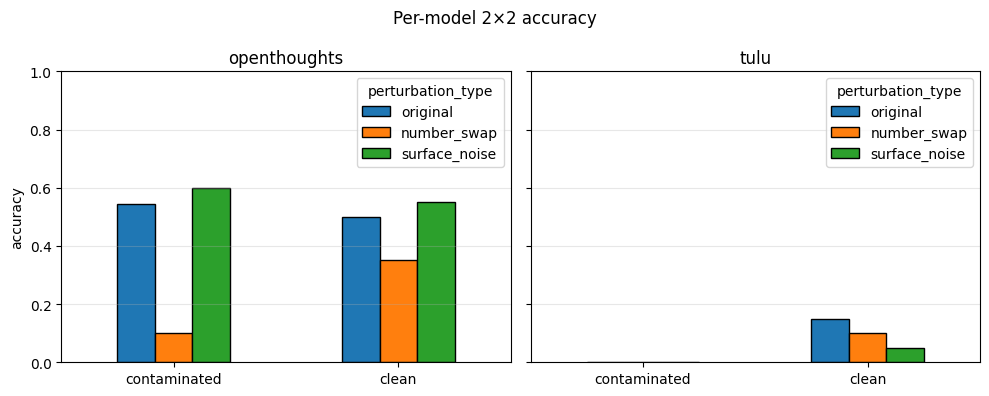

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


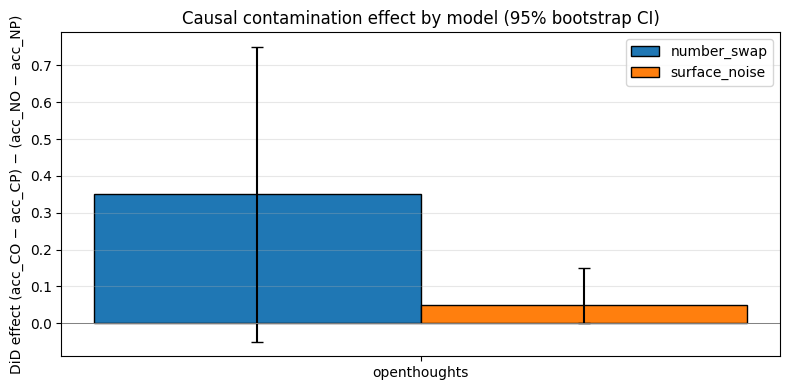

In [17]:
# ── Plots ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

available_models = [m for m in RUN_MODELS if m in df["model"].unique()]

# (a) Per-model 2x2 accuracy bars
n = len(available_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True, squeeze=False)
for ax, model_name in zip(axes[0], available_models):
    sub = df[df.model == model_name]
    means = (sub.groupby(["split", "perturbation_type"])["correct"]
                .apply(lambda s: s.dropna().astype(int).mean())
                .unstack()
                .reindex(index=["contaminated", "clean"],
                         columns=["original", "number_swap", "surface_noise"]))
    means.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(model_name)
    ax.set_ylabel("accuracy")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(means.index, rotation=0)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Per-model 2×2 accuracy")
plt.tight_layout()
plt.show()

# (b) Cross-model DiD with 95% bootstrap CIs
if not results_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    width  = 0.35
    models = sorted(results_df["model"].unique(), key=lambda m: RUN_MODELS.index(m))
    x      = np.arange(len(models))
    for offset, ptype in zip([-width / 2, width / 2], ["number_swap", "surface_noise"]):
        r = (results_df[results_df.perturbation_type == ptype]
                       .set_index("model").reindex(models))
        ax.bar(x + offset, r["did"], width, label=ptype,
               yerr=[r["did"] - r["ci_low"], r["ci_high"] - r["did"]],
               capsize=4, edgecolor="black")
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("DiD effect (acc_CO − acc_CP) − (acc_NO − acc_NP)")
    ax.set_title("Causal contamination effect by model (95% bootstrap CI)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [18]:
# ── F6: θ sensitivity sweep on per-problem Δ (contaminated arm) ────────────────────────
# Δ_i = correct(original) - correct(perturbed). At N=1 this is in {-1, 0, 1};
# the sweep becomes informative only when N_SAMPLES > 1 (continuous Δ).
THETAS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50]

print(f"{'model':<14} {'perturbation':<15} " + "  ".join(f"θ={t:.2f}" for t in THETAS))
print("─" * 95)
for model_name in RUN_MODELS:
    sub = df[(df.model == model_name) & (df.split == "contaminated")]
    if sub.empty:
        continue
    for ptype in ["number_swap", "surface_noise"]:
        pivot = (sub[sub.perturbation_type.isin(["original", ptype])]
                    .pivot_table(index="math500_id",
                                 columns="perturbation_type",
                                 values="correct",
                                 aggfunc="first")
                    .dropna())
        if pivot.empty or "original" not in pivot.columns or ptype not in pivot.columns:
            continue
        deltas = pivot["original"].astype(int) - pivot[ptype].astype(int)
        n      = len(deltas)
        rates  = []
        for theta in THETAS:
            flagged = int((deltas >= theta).sum())
            rates.append(f"{flagged}/{n} ({flagged/n:.0%})")
        print(f"{model_name:<14} {ptype:<15} " + "  ".join(f"{r:>9}" for r in rates))

if N_SAMPLES == 1:
    print("\nNote: at N_SAMPLES=1, Δ is in {-1, 0, 1}, so the sweep is degenerate above θ=0.")

model          perturbation    θ=0.05  θ=0.10  θ=0.15  θ=0.20  θ=0.25  θ=0.30  θ=0.50
───────────────────────────────────────────────────────────────────────────────────────────────
openthoughts   number_swap     5/10 (50%)  5/10 (50%)  5/10 (50%)  5/10 (50%)  5/10 (50%)  5/10 (50%)  5/10 (50%)
openthoughts   surface_noise   0/10 (0%)  0/10 (0%)  0/10 (0%)  0/10 (0%)  0/10 (0%)  0/10 (0%)  0/10 (0%)

Note: at N_SAMPLES=1, Δ is in {-1, 0, 1}, so the sweep is degenerate above θ=0.


In [19]:
# ── Join annotation CSV for similarity_score and Type of contamination (F3, F5) ──────
# Annotation CSV uses dataset='openthoughts_full' for what we call 'openthoughts'.
# S1 is not present in annotations.
if not ANNOT_CSV.exists():
    print(f"[skip] {ANNOT_CSV} not found — F3 and F5 will be skipped.")
    annot = pd.DataFrame()
else:
    annot_raw = pd.read_csv(ANNOT_CSV)
    DS_MAP = {"openthoughts_full": "openthoughts", "tulu": "tulu", "s1": "s1"}
    annot_raw["model"] = annot_raw["dataset"].map(DS_MAP)
    annot = (annot_raw[["model", "math500_id", "similarity_score",
                       "Type of contamination", "Is it contaminated?"]]
             .rename(columns={"Type of contamination": "contam_type",
                              "Is it contaminated?":   "is_contam"}))
    annot["similarity_score"] = pd.to_numeric(annot["similarity_score"], errors="coerce")
    print(f"Annotation rows: {len(annot)}; with similarity score: {annot.similarity_score.notna().sum()}; with type label: {annot.contam_type.isin(['A','B']).sum()}")

    df = df.merge(annot, on=["model", "math500_id"], how="left")
    matched = df[df.split == "contaminated"]["similarity_score"].notna().sum()
    total   = (df.split == "contaminated").sum()
    print(f"Contaminated rows with similarity match: {matched}/{total}")

Annotation rows: 71; with similarity score: 71; with type label: 38
Contaminated rows with similarity match: 7/31


In [20]:
# ── F3: Spearman correlation between training similarity and per-problem Δ ─────────────
from scipy import stats

if "similarity_score" not in df.columns:
    print("[skip] no similarity_score column — annotation CSV not loaded.")
else:
    print(f"{'model':<14} {'perturbation':<15} {'n':>4} {'Spearman r':>12} {'p':>7}")
    print("─" * 60)
    for model_name in RUN_MODELS:
        sub = df[(df.model == model_name) & (df.split == "contaminated")]
        if sub.empty or sub.similarity_score.notna().sum() == 0:
            continue
        for ptype in ["number_swap", "surface_noise"]:
            pivot = (sub[sub.perturbation_type.isin(["original", ptype])]
                        .pivot_table(index=["math500_id", "similarity_score"],
                                     columns="perturbation_type",
                                     values="correct",
                                     aggfunc="first")
                        .dropna()
                        .reset_index())
            if pivot.empty or "original" not in pivot.columns or ptype not in pivot.columns:
                continue
            pivot["delta"] = pivot["original"].astype(int) - pivot[ptype].astype(int)
            if pivot["similarity_score"].nunique() < 2 or pivot["delta"].nunique() < 2:
                print(f"{model_name:<14} {ptype:<15} {len(pivot):>4} {'(constant)':>12} {'─':>7}")
                continue
            r, p = stats.spearmanr(pivot["similarity_score"], pivot["delta"])
            print(f"{model_name:<14} {ptype:<15} {len(pivot):>4} {r:>+12.3f} {p:>7.3f}")

model          perturbation       n   Spearman r       p
────────────────────────────────────────────────────────────
openthoughts   number_swap        2   (constant)       ─
openthoughts   surface_noise      2   (constant)       ─


In [21]:
# ── F5: Type A vs Type B subgroup analysis on per-problem Δ ────────────────────────────
if "contam_type" not in df.columns:
    print("[skip] no contam_type column — annotation CSV not loaded.")
else:
    print(f"{'model':<14} {'perturbation':<15} {'group':<8} {'n':>4} {'mean Δ':>8}    {'MWU p':>7}")
    print("─" * 75)
    for model_name in RUN_MODELS:
        sub = df[(df.model == model_name) & (df.split == "contaminated")]
        if sub.empty or sub.contam_type.isin(["A", "B"]).sum() == 0:
            continue
        for ptype in ["number_swap", "surface_noise"]:
            pivot = (sub[sub.perturbation_type.isin(["original", ptype])]
                        .pivot_table(index=["math500_id", "contam_type"],
                                     columns="perturbation_type",
                                     values="correct",
                                     aggfunc="first")
                        .dropna()
                        .reset_index())
            if pivot.empty or "original" not in pivot.columns or ptype not in pivot.columns:
                continue
            pivot["delta"] = pivot["original"].astype(int) - pivot[ptype].astype(int)
            a = pivot.loc[pivot.contam_type == "A", "delta"].to_numpy()
            b = pivot.loc[pivot.contam_type == "B", "delta"].to_numpy()
            if len(a) == 0 and len(b) == 0:
                continue
            try:
                u, p = stats.mannwhitneyu(a, b, alternative="greater") if (len(a) and len(b)) else (float('nan'), float('nan'))
            except ValueError:
                u, p = float('nan'), float('nan')
            mean_a = a.mean() if len(a) else float('nan')
            mean_b = b.mean() if len(b) else float('nan')
            print(f"{model_name:<14} {ptype:<15} {'A':<8} {len(a):>4} {mean_a:>+8.3f}    {p:>7.3f}")
            print(f"{model_name:<14} {ptype:<15} {'B':<8} {len(b):>4} {mean_b:>+8.3f}")
    print("\nMWU one-sided H1: Type A Δ > Type B Δ (recitation should be stronger for near-paraphrases).")

model          perturbation    group       n   mean Δ      MWU p
───────────────────────────────────────────────────────────────────────────
openthoughts   number_swap     A           1   +1.000        nan
openthoughts   number_swap     B           0     +nan
openthoughts   surface_noise   A           1   +0.000        nan
openthoughts   surface_noise   B           0     +nan

MWU one-sided H1: Type A Δ > Type B Δ (recitation should be stronger for near-paraphrases).


### Accuracy Comparison: Contaminated vs Clean by Subject and Level
Aggregates the accuracy across different subjects and difficulty levels, plotting a side-by-side comparison of the contaminated and clean splits.

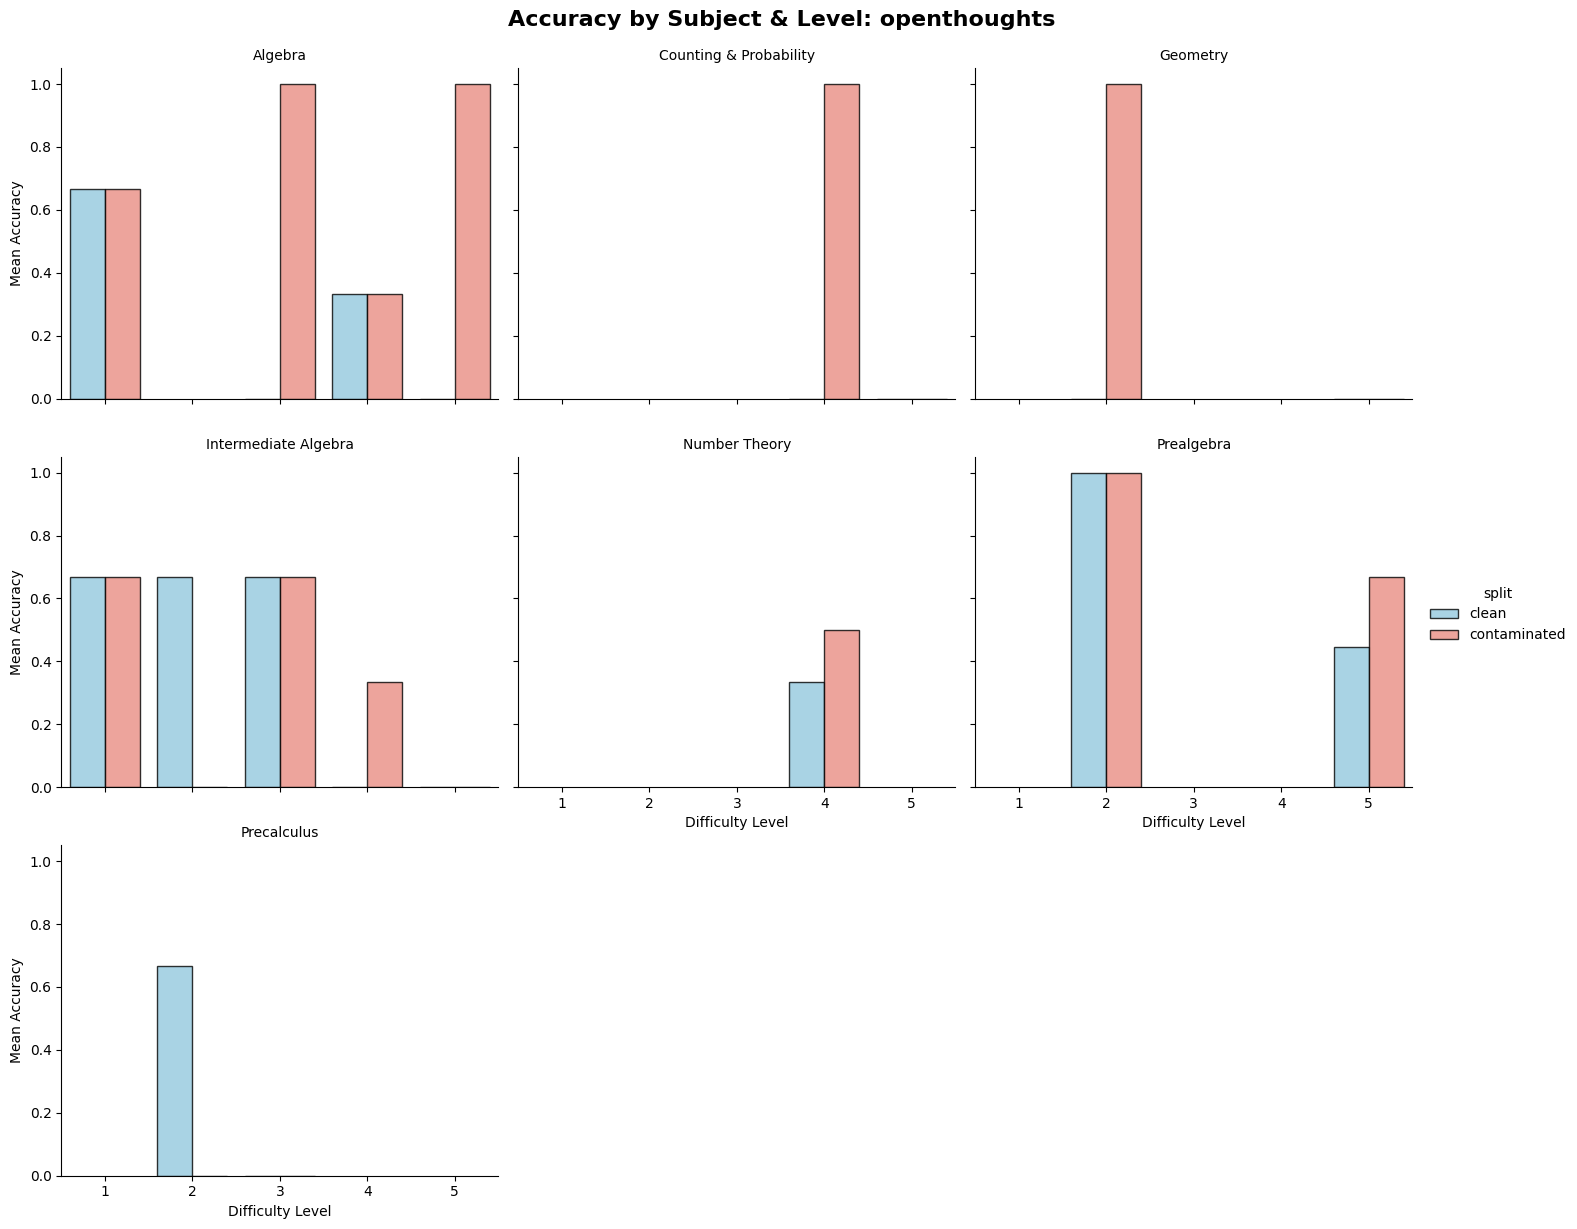

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Explicitly load the OpenThoughts traces so this cell can run independently
OUT_DIR = Path("/content/drive/MyDrive/CS288/did_traces")
fp = OUT_DIR / "did_traces_openthoughts.jsonl"

traces = []
if fp.exists():
    with open(fp) as f:
        for line in f:
            try:
                traces.append(json.loads(line))
            except:
                pass

if traces:
    df_plot = pd.DataFrame(traces)

    # Ensure data is properly formatted for aggregation
    df_plot['correct'] = df_plot['correct'].astype(float)
    df_plot['level'] = pd.to_numeric(df_plot['level'], errors='coerce')

    # Filter for openthoughts ONLY
    df_plot = df_plot[df_plot['model'] == 'openthoughts']

    # Aggregate accuracy by model, subject, level, and split
    agg_df = df_plot.groupby(['model', 'subject', 'level', 'split'])['correct'].mean().reset_index()
    agg_df.rename(columns={'correct': 'accuracy'}, inplace=True)

    # Sort for better plotting
    agg_df = agg_df.sort_values(by=['subject', 'level'])

    if not agg_df.empty:
        g = sns.catplot(
            data=agg_df,
            kind='bar',
            x='level',
            y='accuracy',
            hue='split',
            col='subject',
            col_wrap=3,
            height=4,
            aspect=1.2,
            palette={'contaminated': 'salmon', 'clean': 'skyblue'},
            edgecolor='black',
            alpha=0.8
        )
        g.fig.suptitle("Accuracy by Subject & Level: openthoughts", y=1.02, fontsize=16, fontweight='bold')
        g.set_axis_labels("Difficulty Level", "Mean Accuracy")
        g.set_titles("{col_name}")

        # Set y-axis to 0-1 for accuracy proportion
        for ax in g.axes.flatten():
            ax.set_ylim(0, 1.05)

        plt.show()
    else:
        print("No valid openthoughts data found after aggregation.")
else:
    print("No data found for openthoughts model (did_traces_openthoughts.jsonl is missing or empty).")